# Benchmarking and Evaluation

## Prepare Environment

Set up the notebook environment with necessary imports and create reusable utility functions for tasks we'll repeat across all datasets.

In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
import optuna
import numpy as np
import pandas as pd
from scipy.stats import iqr
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.linear_model import Ridge

import utils
from sgkan import sgkan_parameter_search as sps
from sgkan import sgkan_model
from hkan.hkan import (
    Sigmoid, Gaussian, ReLU, Tanh, Softplus, Identity,
)
import visualize
import swim as ss
import evaluation_metrics as em
random_seed = 0

/Users/gizemnurdal/miniconda3/envs/swim-meets-kans/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Helper functions for data handling, model evaluation, and statistical analysis across multiple runs.

In [2]:
def create_export_seed_results(seed_results, name):
    """Create dataframe from the seed results."""
    rows = []
    for i, r in enumerate(seed_results):
        rows.append({
            "seed": i,
            "train_mae": r["train"]["mae"],
            "train_rmse": r["train"]["rmse"],
            "train_inference_time_secs": r["train"]["inference_time_secs"],
            "test_mae": r["test"]["mae"],
            "test_rmse": r["test"]["rmse"],
            "test_inference_time_secs": r["test"]["inference_time_secs"],
        })

    seed_results_df = pd.DataFrame(rows)
    seed_results_df.to_csv(f"data/{name}.csv", index=False)
    return seed_results_df

def summarize_metrics(df, name):
    """Calculate IQR and Median values of RMSE and MAE metrics."""
    summary = {
        "model": name,
        "train_rmse_median": df["train_rmse"].median(),
        "train_rmse_iqr": iqr(df["train_rmse"]),
        "test_rmse_median": df["test_rmse"].median(),
        "test_rmse_iqr": iqr(df["test_rmse"]),
    }
    return summary


In [3]:
def run_sgkan_seed_experiments(x_train, y_train, x_test, y_test, layer_configs, n_runs=50):
    """Train SGKAN model n_runs times with different random seeds."""
    n_runs_results = []
    for s in range(n_runs):
        print(f"Seed: {s}")
        updated_configs = [config.copy() for config in layer_configs]
        for config in updated_configs:
            config['seed'] = s
        
        model = sgkan_model.SGKANModel(updated_configs).fit(x_train, y_train)
        results = em.evaluate(model, x_train, y_train, x_test, y_test)
        n_runs_results.append(results)
    
    return n_runs_results

In [4]:
def plot_hypothesis_1_results(results_df):
    """Plot Hypothesis 1 comparison results for SGKAN (swim), SGKAN (random), and HKAN."""
    plt.figure(figsize=(12, 6))

    plt.plot(results_df['layer_width'], results_df['sgkan_swim_train_rmse'], marker='o', label='SGKAN SWIM Train', color='#1f77b4')
    plt.plot(results_df['layer_width'], results_df['sgkan_swim_test_rmse'], marker='s', label='SGKAN SWIM Test', color='#1f77b4', linestyle='--')

    plt.plot(results_df['layer_width'], results_df['sgkan_random_train_rmse'], marker='o', label='SGKAN Random Train', color='#ff7f0e')
    plt.plot(results_df['layer_width'], results_df['sgkan_random_test_rmse'], marker='s', label='SGKAN Random Test', color='#ff7f0e', linestyle='--')

    plt.plot(results_df['layer_width'], results_df['hkan_train_rmse'], marker='o', label='HKAN Train', color='#2ca02c')
    plt.plot(results_df['layer_width'], results_df['hkan_test_rmse'], marker='s', label='HKAN Test', color='#2ca02c', linestyle='--')

    plt.xlabel('Layer Width')
    plt.ylabel('RMSE')
    plt.xscale('log')
    plt.yscale('log')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_first_layer_local_edge_r2_summary(layer_neurons):
    """
    Boxplot of train-local R^2 across all nodes q, one box per input p,
    for the FIRST layer only. Unlike plot_first_layer_featurewise_r2_summary
    (which scores each edge against the full y_train), this scores each
    edge only against the local points it was actually fit on.
    """
    neurons = layer_neurons[0]
    n_vars_out = len(neurons)
    n_vars_in = len(neurons[0]["edge_params"])

    data, labels = [], []
    for p in range(n_vars_in):
        r2_vals = [
            r2_score(neurons[q]["edge_params"][p]["local_y"],
                     neurons[q]["edge_params"][p]["local_pred"])
            for q in range(n_vars_out)
        ]
        data.append(r2_vals)
        labels.append(f"p={p}")

    _, ax = plt.subplots(figsize=(1.5 * n_vars_in + 2, 4))
    ax.boxplot(data, tick_labels=labels, showmeans=True)
    ax.set_title(f"Layer 1: Local R² distribution per input variable ({n_vars_out} nodes)")
    ax.set_ylabel(r"$R^2$ (local)")
    ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
    plt.tight_layout()
    plt.show()

In [5]:
def load_dataset(dataset_prefix: str):
    """Load dataset using dataset prefix."""
    # base data directory
    DATA_DIR = os.path.join(os.getcwd(), "data")
    # load train and test set
    trn = np.loadtxt(f"{DATA_DIR}/{dataset_prefix.upper()}_trn.csv", delimiter=",")
    tst = np.loadtxt(f"{DATA_DIR}/{dataset_prefix.upper()}_tst.csv", delimiter=",")
    # slice train and test set
    x_train, y_train = trn[:, :-1], trn[:, -1]
    x_test,  y_test  = tst[:, :-1], tst[:, -1]
    
    print("x_train shape:", x_train.shape)
    print("y_train shape:", y_train.shape)
    print("x_test shape:", x_test.shape)
    print("y_test shape:", y_test.shape)

    return x_train, x_test, y_train, y_test

tf1_x_train, tf1_x_test, tf1_y_train, tf1_y_test = load_dataset("tf1")
tf2_x_train, tf2_x_test, tf2_y_train, tf2_y_test = load_dataset("tf2")
tf3_x_train, tf3_x_test, tf3_y_train, tf3_y_test = load_dataset("tf3")
tf4_x_train, tf4_x_test, tf4_y_train, tf4_y_test = load_dataset("tf4")
tf5_x_train, tf5_x_test, tf5_y_train, tf5_y_test = load_dataset("tf5")

x_train shape: (5000, 2)
y_train shape: (5000,)
x_test shape: (10000, 2)
y_test shape: (10000,)
x_train shape: (5000, 2)
y_train shape: (5000,)
x_test shape: (10000, 2)
y_test shape: (10000,)
x_train shape: (5000, 2)
y_train shape: (5000,)
x_test shape: (10000, 2)
y_test shape: (10000,)
x_train shape: (3750, 10)
y_train shape: (3750,)
x_test shape: (1250, 10)
y_test shape: (1250,)
x_train shape: (5000, 2)
y_train shape: (5000,)
x_test shape: (10000, 2)
y_test shape: (10000,)


## TF1

For TF1, we'll find the best SGKAN configuration through hyperparameter optimization, then run a robustness test with 50 random seeds to compare against our HKAN reproduction, configured with the paper's best reported hyperparameters. We'll also explore how layer width impacts performance and which input features matter most.

### Sanity Check

Sanity check that the model runs without errors. This serves as a basic test before moving to optimization and comparison experiments.

[build_sgkan_stack] Layer 1: pair_selection_strategy = 'swim'
[fit_layer] pair_selection_strategy = 'swim' (layer_width=100, D_in=2)
[fit_layer] local-window method counts over 200 edges: {'interval_capped': 114, 'interval': 86}
[build_sgkan_stack] Layer 2: pair_selection_strategy = 'swim'
[fit_layer] pair_selection_strategy = 'swim' (layer_width=1, D_in=100)
[fit_layer] local-window method counts over 100 edges: {'interval': 74, 'interval_capped': 26}
TF1 SGKAN train R2: 0.992241983672421


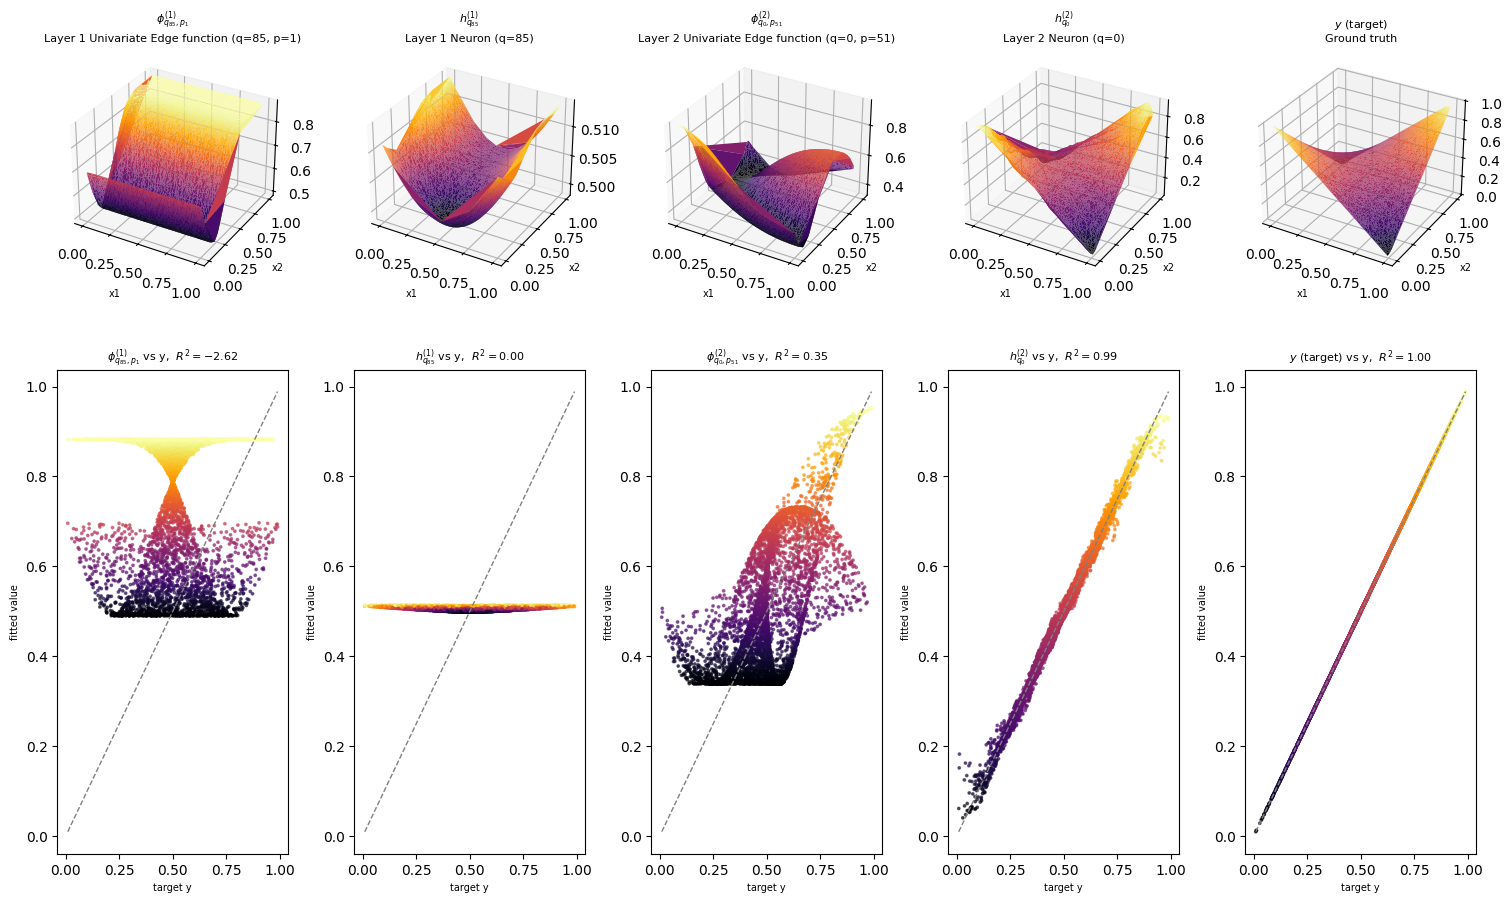

In [6]:
tf1_sgkan_layer_swim_configs = [
    {"layer_width": 100, "num_inducing": 75, "pair_selection_strategy": "swim", "alpha_edge": 1, "alpha_neuron": 0,
     "max_local_points": 1000, "kernel_type": "rbf", "seed": random_seed, "sigma_scale": 1},
    {"layer_width": 1, "num_inducing": 75, "pair_selection_strategy": "swim", "alpha_edge": 1, "alpha_neuron": 0,
     "max_local_points": 1000, "kernel_type": "rbf", "seed": random_seed, "sigma_scale": 1},
]
# A stage item in stages list consists of (layer_idx, phi[q, p, :] edge function results, layer_output) 
tf1_sgkan_stages, tf1_sgkan_ytrain_hat, tf1_sgkan_layer_neurons = sgkan_model.build_sgkan_stack(tf1_x_train, tf1_y_train, tf1_sgkan_layer_swim_configs)
print("TF1 SGKAN train R2:", r2_score(tf1_y_train, tf1_sgkan_ytrain_hat))

visualize.plot_model_stages(tf1_x_train, tf1_y_train, tf1_sgkan_stages, block_idx="random", seed=0)

In [7]:
tf1_sgkan_model = sgkan_model.SGKANModel(tf1_sgkan_layer_swim_configs).fit(tf1_x_train, tf1_y_train)

tf1_sgkan_results = em.evaluate(
    tf1_sgkan_model, tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test
)
em.print_results(tf1_sgkan_results)

[fit_layer] pair_selection_strategy = 'swim' (layer_width=100, D_in=2)
[fit_layer] local-window method counts over 200 edges: {'interval_capped': 114, 'interval': 86}
[fit_layer] pair_selection_strategy = 'swim' (layer_width=1, D_in=100)
[fit_layer] local-window method counts over 100 edges: {'interval': 74, 'interval_capped': 26}
[SGKANModel.fit] Total fit duration: 2.8795s
Metric          Train                Test                
-------------------------------------------------------
MAE             1.063578e-02         1.130915e-02        
RMSE            1.464964e-02         1.637684e-02        
-------------------------------------------------------
Inference (s)   1.233789             2.103606            


### Optuna - Parameter Search 

Find the best layer configuration for TF1 dataset.

In [8]:
tf1_result = sps.study_optuna_sgkan(
    "tf1", tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test,
    n_trials=375
)

Results found for tf1. Loading from data/tf1_sgkan_optuna_search.csv
Best Validation RMSE:   0.000000001706430
Best Test RMSE:          0.000000239241409
Best layer_width:        1000
Best num_inducing:       10
Best alpha_edge:         1.000e+01
Best alpha_neuron:       0.000e+00
Best kernel_type:        rbf

All 375 trials:
     number         value  params_layer_width  params_num_inducing  params_alpha_edge  params_alpha_neuron params_kernel_type      val_rmse     test_rmse
0         0  0.0000785636                1000                   50              0.001                    0             matern  0.0000785636           NaN
1         1  0.0579499301                1000                   25              1.000                    0           periodic  0.0579499301           NaN
2         2  0.0000007765                 500                   50             10.000                    0                rbf  0.0000007765           NaN
3         3  0.0586263567                 500           

In [9]:
# Use best parameter configuration to fit an SGKAN model again
best_tf1_configs = tf1_result["layer_configs"]
best_tf1_configs

[{'layer_width': 1000,
  'num_inducing': 10,
  'pair_selection_strategy': 'swim',
  'alpha_edge': 10.0,
  'alpha_neuron': 0.0,
  'max_local_points': 1000,
  'kernel_type': 'rbf',
  'seed': 0,
  'sigma_scale': 1},
 {'layer_width': 1,
  'num_inducing': 10,
  'pair_selection_strategy': 'swim',
  'alpha_edge': 10.0,
  'alpha_neuron': 0.0,
  'max_local_points': 1000,
  'kernel_type': 'rbf',
  'seed': 0,
  'sigma_scale': 1}]

In [10]:
tf1_sgkan_optuna_df = pd.read_csv("data/tf1_sgkan_optuna_search.csv")
tf1_sgkan_optuna_df.sort_values("val_rmse").head(5)

,number,value,datetime_start,datetime_complete,duration,params_alpha_edge,params_alpha_neuron,params_kernel_type,params_layer_width,params_num_inducing,...,fit_duration_sec,kernel_type,user_attrs_layer_width,user_attrs_num_inducing,sigma_scale,val_rmse,system_attrs_grid_id,system_attrs_search_space,state,test_rmse
305,305,0.0000000017,2026-07-30 11:41:30.648706,2026-07-30 11:41:37.058882,6.410176,10.000,0,rbf,1000,10,...,6.075455458,rbf,1000,10,1,0.0000000017,305,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,0.0000002392
287,287,0.0000000021,2026-07-30 11:37:02.464521,2026-07-30 11:37:08.113075,5.648554,0.001,0,rbf,1000,10,...,5.311119500,rbf,1000,10,1,0.0000000021,287,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,NaN
70,70,0.0000000025,2026-07-30 10:59:25.284068,2026-07-30 10:59:49.011180,23.727112,0.100,0,rbf,1000,75,...,21.907763917,rbf,1000,75,1,0.0000000025,70,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,NaN
374,374,0.0000000027,2026-07-30 11:55:05.863976,2026-07-30 11:55:23.650186,17.786210,0.100,0,rbf,1000,50,...,16.019644166,rbf,1000,50,1,0.0000000027,374,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,NaN
83,83,0.0000000033,2026-07-30 11:02:13.905632,2026-07-30 11:02:44.458416,30.552784,10.000,0,rbf,1000,100,...,28.553638917,rbf,1000,100,1,0.0000000033,83,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,NaN


In [11]:
best_tf1_sgkan_model = sgkan_model.SGKANModel(best_tf1_configs).fit(tf1_x_train, tf1_y_train)

best_tf1_sgkan_results = em.evaluate(
    best_tf1_sgkan_model, tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test
)
em.print_results(best_tf1_sgkan_results)

[fit_layer] pair_selection_strategy = 'swim' (layer_width=1000, D_in=2)
[fit_layer] local-window method counts over 2000 edges: {'interval_capped': 1204, 'interval': 795, 'knn_fallback': 1}
[fit_layer] pair_selection_strategy = 'swim' (layer_width=1, D_in=1000)
[fit_layer] local-window method counts over 1000 edges: {'interval': 646, 'interval_capped': 353, 'knn_fallback': 1}
[SGKANModel.fit] Total fit duration: 6.4327s
Metric          Train                Test                
-------------------------------------------------------
MAE             6.064952e-08         9.680470e-08        
RMSE            7.994163e-08         2.392414e-07        
-------------------------------------------------------
Inference (s)   1.528361             3.476013            


In [12]:
# Try best parameter configuration but without SWIM (random projections) this time
# Aim is to see if using SWIM matters
random_best_tf1_configs = [{'layer_width': 1000,
  'num_inducing': 10,
  'pair_selection_strategy': 'random',
  'alpha_edge': 10,
  'alpha_neuron': 0,
  'max_local_points': 1000,
  'kernel_type': 'rbf',
  'seed': 0,
  'sigma_scale': 1},
 {'layer_width': 1,
  'num_inducing': 10,
  'pair_selection_strategy': 'random',
  'alpha_edge': 10,
  'alpha_neuron': 0,
  'max_local_points': 1000,
  'kernel_type': 'rbf',
  'seed': 0,
  'sigma_scale': 1}]

In [13]:
random_best_tf1_sgkan_model = sgkan_model.SGKANModel(random_best_tf1_configs).fit(tf1_x_train, tf1_y_train)

random_best_tf1_sgkan_results = em.evaluate(
    random_best_tf1_sgkan_model, tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test
)
em.print_results(random_best_tf1_sgkan_results)

[fit_layer] pair_selection_strategy = 'random' (layer_width=1000, D_in=2)
[fit_layer] local-window method counts over 2000 edges: {'interval_capped': 1253, 'interval': 744, 'knn_fallback': 3}
[fit_layer] pair_selection_strategy = 'random' (layer_width=1, D_in=1000)
[fit_layer] local-window method counts over 1000 edges: {'interval': 798, 'interval_capped': 197, 'knn_fallback': 5}
[SGKANModel.fit] Total fit duration: 6.4871s
Metric          Train                Test                
-------------------------------------------------------
MAE             2.539606e-04         3.183563e-04        
RMSE            3.200597e-04         4.497476e-04        
-------------------------------------------------------
Inference (s)   1.830290             3.567854            


### 50 seed results

Run the best SGKAN model 50 times with different random seeds to compute median and IQR of RMSE, matching the methodology from HKAN's paper for fair comparison. This statistical approach accounts for the randomness in pair selection and provides a robust measure of model performance variability.

In [14]:
tf1_50_runs_path = "data/tf1_sgkan_50_run_results.csv"

 # Load cached results if they exist
if os.path.exists(tf1_50_runs_path):
    tf1_50_runs_df = pd.read_csv("data/tf1_sgkan_50_run_results.csv")
else:
    tf1_50_runs = run_sgkan_seed_experiments(tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test, best_tf1_configs, n_runs=50)
    tf1_50_runs_df = create_export_seed_results(tf1_50_runs, "tf1_sgkan_50_run_results")

tf1_50_runs_df.head()

,seed,train_mae,train_rmse,train_inference_time_secs,test_mae,test_rmse,test_inference_time_secs
0,0,6.0649517959e-08,0.0000000799,2.279685833,0.0000000968,0.0000002392,2.873051542
1,1,2.5252738694e-10,0.0000000003,2.081338292,0.0000000004,0.0000000024,2.864471708
2,2,8.6827358855e-11,0.0000000001,1.476839917,0.0000000003,0.0000000063,2.770253584
3,3,2.0184985322e-09,0.0000000026,1.386089000,0.0000000041,0.0000000200,2.710769667
4,4,1.6353201419e-10,0.0000000002,1.374658333,0.0000000003,0.0000000027,2.786007833


In [15]:
summarize_metrics(tf1_50_runs_df, "SGKAN SWIM")

{'model': 'SGKAN SWIM',
 'train_rmse_median': 3.059112325181784e-09,
 'train_rmse_iqr': 5.581155393647375e-08,
 'test_rmse_median': 1.3266688766021089e-08,
 'test_rmse_iqr': 1.9766348896891833e-07}

### Hypothesis 1

Increasing layer width (other parameters are constant) vs. RMSE for different models HKAN, SGKAN swim and SGKAN random

Compare how increasing the first layer width affects performance across SGKAN (SWIM), SGKAN (random), and HKAN. All other parameters stay fixed to isolate the width effect. The goal is to understand whether wider layers consistently improve predictions and if this trend differs between the algorithms.

In [16]:
# Best TF1 HKAN configuration from the paper
tf1_hkan_layer_configs = [
    dict(layer=0, n_vars_out=932, n_basis=2, centers="random_data_points", basis_fn=Sigmoid(s=1), expanding_base_regressor=Ridge(alpha=0.1)),
    dict(layer=1, n_vars_out=1, n_basis=13, centers="random_data_points", basis_fn=Tanh(s=33), expanding_base_regressor=Ridge(alpha=10)),
]

In [ ]:
tf1_hypothesis_1_path = "data/tf1_hypothesis_1_results_df.csv"

if os.path.exists(tf1_hypothesis_1_path):
    tf1_hypothesis_1_results_df = pd.read_csv("data/tf1_hypothesis_1_results_df.csv")
else:
    # Define layer widths
    layer_widths = [2, 10, 25, 50, 100, 250, 500, 750, 1000]

    # Results storage
    results = {
        'sgkan_swim': {'widths': [], 'train_rmse': [], 'test_rmse': []},
        'sgkan_random': {'widths': [], 'train_rmse': [], 'test_rmse': []},
        'hkan': {'widths': [], 'train_rmse': [], 'test_rmse': []}
    }

    # SGKAN with SWIM
    print("Testing SGKAN with SWIM pair selection...")
    for width in layer_widths:
        config = [c.copy() for c in best_tf1_configs]
        config[0]['layer_width'] = width
        model = sgkan_model.SGKANModel(config).fit(tf1_x_train, tf1_y_train)
        eval_results = em.evaluate(model, tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test)
        results['sgkan_swim']['widths'].append(width)
        results['sgkan_swim']['train_rmse'].append(eval_results['train']['rmse'])
        results['sgkan_swim']['test_rmse'].append(eval_results['test']['rmse'])
        print(f"  Width {width}: Train RMSE={eval_results['train']['rmse']:.6e}, Test RMSE={eval_results['test']['rmse']:.6e}")

    # SGKAN with random pair selection
    print("\nTesting SGKAN with random pair selection...")
    for width in layer_widths:
        config = [c.copy() for c in best_tf1_configs]
        config[0]['pair_selection_strategy'] = 'random'
        config[0]['layer_width'] = width
        config[1]['pair_selection_strategy'] = 'random'
        model = sgkan_model.SGKANModel(config).fit(tf1_x_train, tf1_y_train)
        eval_results = em.evaluate(model, tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test)
        results['sgkan_random']['widths'].append(width)
        results['sgkan_random']['train_rmse'].append(eval_results['train']['rmse'])
        results['sgkan_random']['test_rmse'].append(eval_results['test']['rmse'])
        print(f"  Width {width}: Train RMSE={eval_results['train']['rmse']:.6e}, Test RMSE={eval_results['test']['rmse']:.6e}")

    # HKAN with best config
    print("\nTesting HKAN...")
    for width in layer_widths:
        config = [c.copy() for c in tf1_hkan_layer_configs]
        config[0]['n_vars_out'] = width
        model = utils.build_hkan_model_from_configs(config, tqdm_disable=True)
        utils.fit_hkan(model, tf1_x_train, tf1_y_train)
        eval_results = em.evaluate(model, tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test)
        results['hkan']['widths'].append(width)
        results['hkan']['train_rmse'].append(eval_results['train']['rmse'])
        results['hkan']['test_rmse'].append(eval_results['test']['rmse'])
        print(f"  Width {width}: Train RMSE={eval_results['train']['rmse']:.6e}, Test RMSE={eval_results['test']['rmse']:.6e}")

    # Display results
    tf1_hypothesis_1_results_df = pd.DataFrame({
        'layer_width': layer_widths,
        'sgkan_swim_train_rmse': results['sgkan_swim']['train_rmse'],
        'sgkan_swim_test_rmse': results['sgkan_swim']['test_rmse'],
        'sgkan_random_train_rmse': results['sgkan_random']['train_rmse'],
        'sgkan_random_test_rmse': results['sgkan_random']['test_rmse'],
        'hkan_train_rmse': results['hkan']['train_rmse'],
        'hkan_test_rmse': results['hkan']['test_rmse']
    })
    tf1_hypothesis_1_results_df.to_csv("data/tf1_hypothesis_1_results_df.csv")

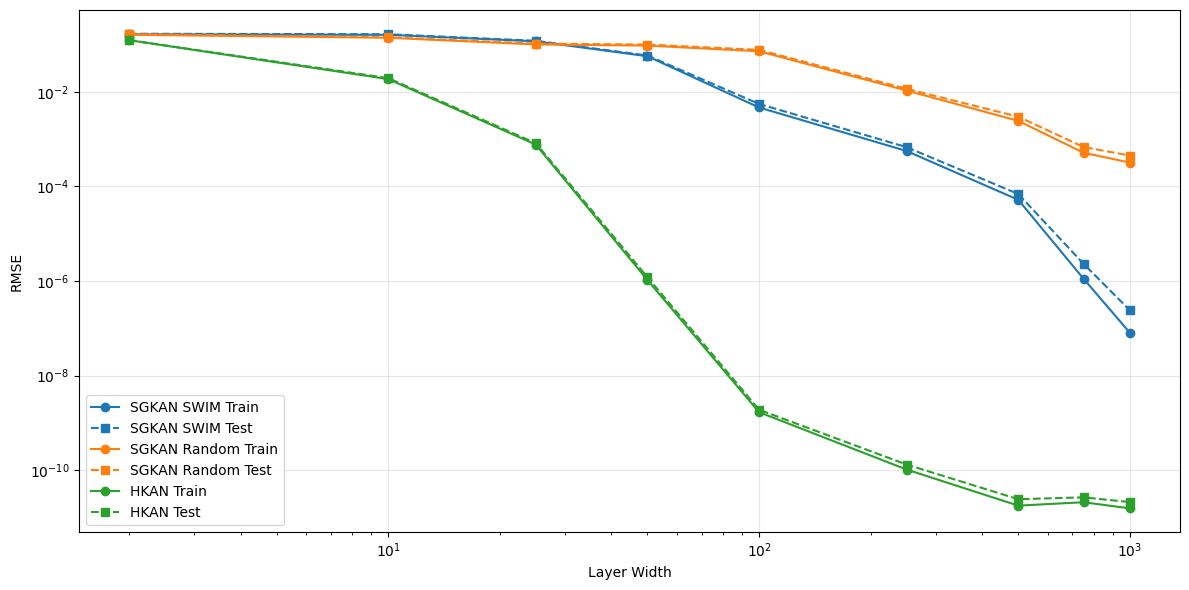

In [18]:
plot_hypothesis_1_results(tf1_hypothesis_1_results_df)

In [19]:
tf1_hypothesis_1_results_df

,Unnamed: 0,layer_width,sgkan_swim_train_rmse,sgkan_swim_test_rmse,sgkan_random_train_rmse,sgkan_random_test_rmse,hkan_train_rmse,hkan_test_rmse
0,0,2,0.1659525402,0.1703936340,0.1622071605,0.1669952897,1.2453329531e-01,1.2499299421e-01
1,1,10,0.1616556899,0.1662264719,0.1400448572,0.1434872793,1.8703071068e-02,1.9599050467e-02
2,2,25,0.1180091895,0.1207917562,0.1010928547,0.1053612043,7.6969371376e-04,8.2382167854e-04
3,3,50,0.0569604474,0.0590020493,0.0955559497,0.1005402916,1.0510134941e-06,1.2051193488e-06
4,4,100,0.0046915159,0.0055719477,0.0725610558,0.0776182789,1.6798511827e-09,1.8892830570e-09
5,5,250,0.0005621984,0.0006776956,0.0107000061,0.0116380946,1.0243567650e-10,1.3079957827e-10
6,6,500,0.0000521574,0.0000692462,0.0024420833,0.0029895795,1.7697896419e-11,2.4160978850e-11
7,7,750,0.0000011131,0.0000023033,0.0005167182,0.0006821127,2.0875994216e-11,2.6475926745e-11
8,8,1000,0.0000000799,0.0000002392,0.0003200597,0.0004497476,1.5465015885e-11,2.0994428870e-11


### Explore Feature importances and Layers

Examine how well each input feature is being captured by the first layer of the best model. This helps us understand which input dimensions are most important and how the model processes the input space.

In [20]:
best_tf1_configs

[{'layer_width': 1000,
  'num_inducing': 10,
  'pair_selection_strategy': 'swim',
  'alpha_edge': 10.0,
  'alpha_neuron': 0.0,
  'max_local_points': 1000,
  'kernel_type': 'rbf',
  'seed': 0,
  'sigma_scale': 1},
 {'layer_width': 1,
  'num_inducing': 10,
  'pair_selection_strategy': 'swim',
  'alpha_edge': 10.0,
  'alpha_neuron': 0.0,
  'max_local_points': 1000,
  'kernel_type': 'rbf',
  'seed': 0,
  'sigma_scale': 1}]

[build_sgkan_stack] Layer 1: pair_selection_strategy = 'swim'
[fit_layer] pair_selection_strategy = 'swim' (layer_width=1000, D_in=2)
[fit_layer] local-window method counts over 2000 edges: {'interval_capped': 1204, 'interval': 795, 'knn_fallback': 1}
[build_sgkan_stack] Layer 2: pair_selection_strategy = 'swim'
[fit_layer] pair_selection_strategy = 'swim' (layer_width=1, D_in=1000)
[fit_layer] local-window method counts over 1000 edges: {'interval': 646, 'interval_capped': 353, 'knn_fallback': 1}


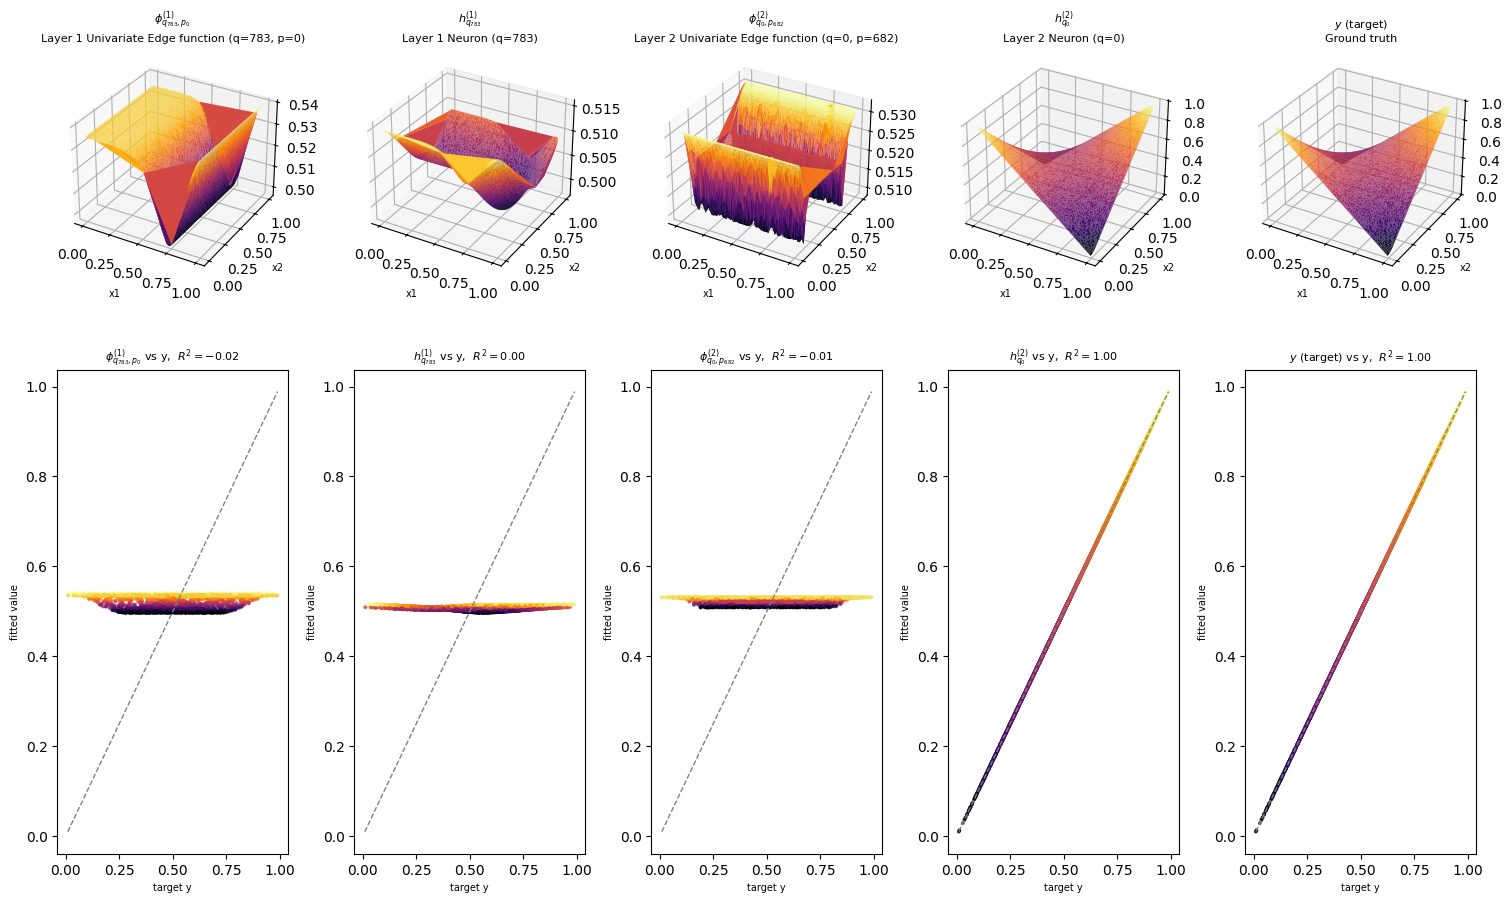

In [21]:
best_tf1_sgkan_stages, best_tf1_sgkan_ytrain_hat, best_tf1_sgkan_layer_neurons = sgkan_model.build_sgkan_stack(tf1_x_train, tf1_y_train, best_tf1_configs)
visualize.plot_model_stages(tf1_x_train, tf1_y_train, best_tf1_sgkan_stages, block_idx="random")

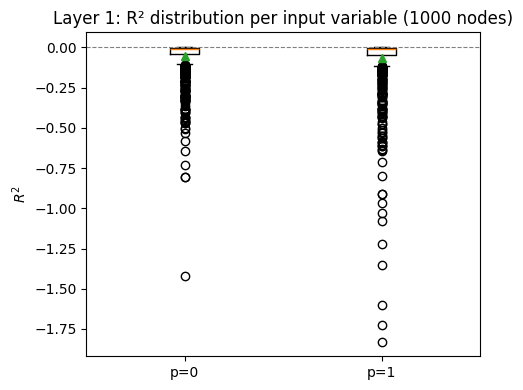

In [22]:
visualize.plot_first_layer_featurewise_r2_summary(best_tf1_sgkan_stages, tf1_y_train)

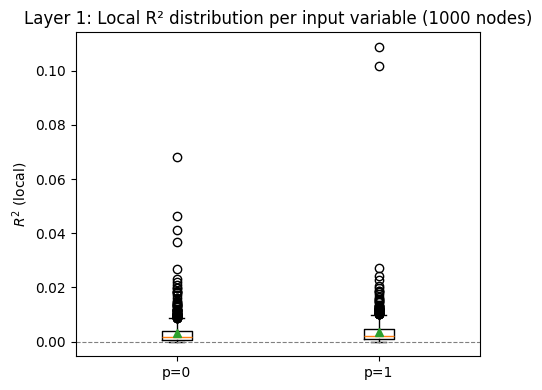

In [23]:
plot_first_layer_local_edge_r2_summary(best_tf1_sgkan_layer_neurons)

## TF2

For TF2, we'll find the best SGKAN configuration through hyperparameter optimization, then run a robustness test with 50 random seeds to compare against our HKAN reproduction, configured with the paper's best reported hyperparameters. We'll also explore how layer width impacts performance and which input features matter most.

### Sanity Check

Sanity check that the model runs without errors. This serves as a basic test before moving to optimization and comparison experiments.

[build_sgkan_stack] Layer 1: pair_selection_strategy = 'swim'
[fit_layer] pair_selection_strategy = 'swim' (layer_width=500, D_in=2)
[fit_layer] local-window method counts over 1000 edges: {'interval_capped': 541, 'interval': 457, 'knn_fallback': 2}
[build_sgkan_stack] Layer 2: pair_selection_strategy = 'swim'
[fit_layer] pair_selection_strategy = 'swim' (layer_width=1, D_in=500)
[fit_layer] local-window method counts over 500 edges: {'interval_capped': 412, 'interval': 88}
TF2 SGKAN train R2: 0.5730622647789694


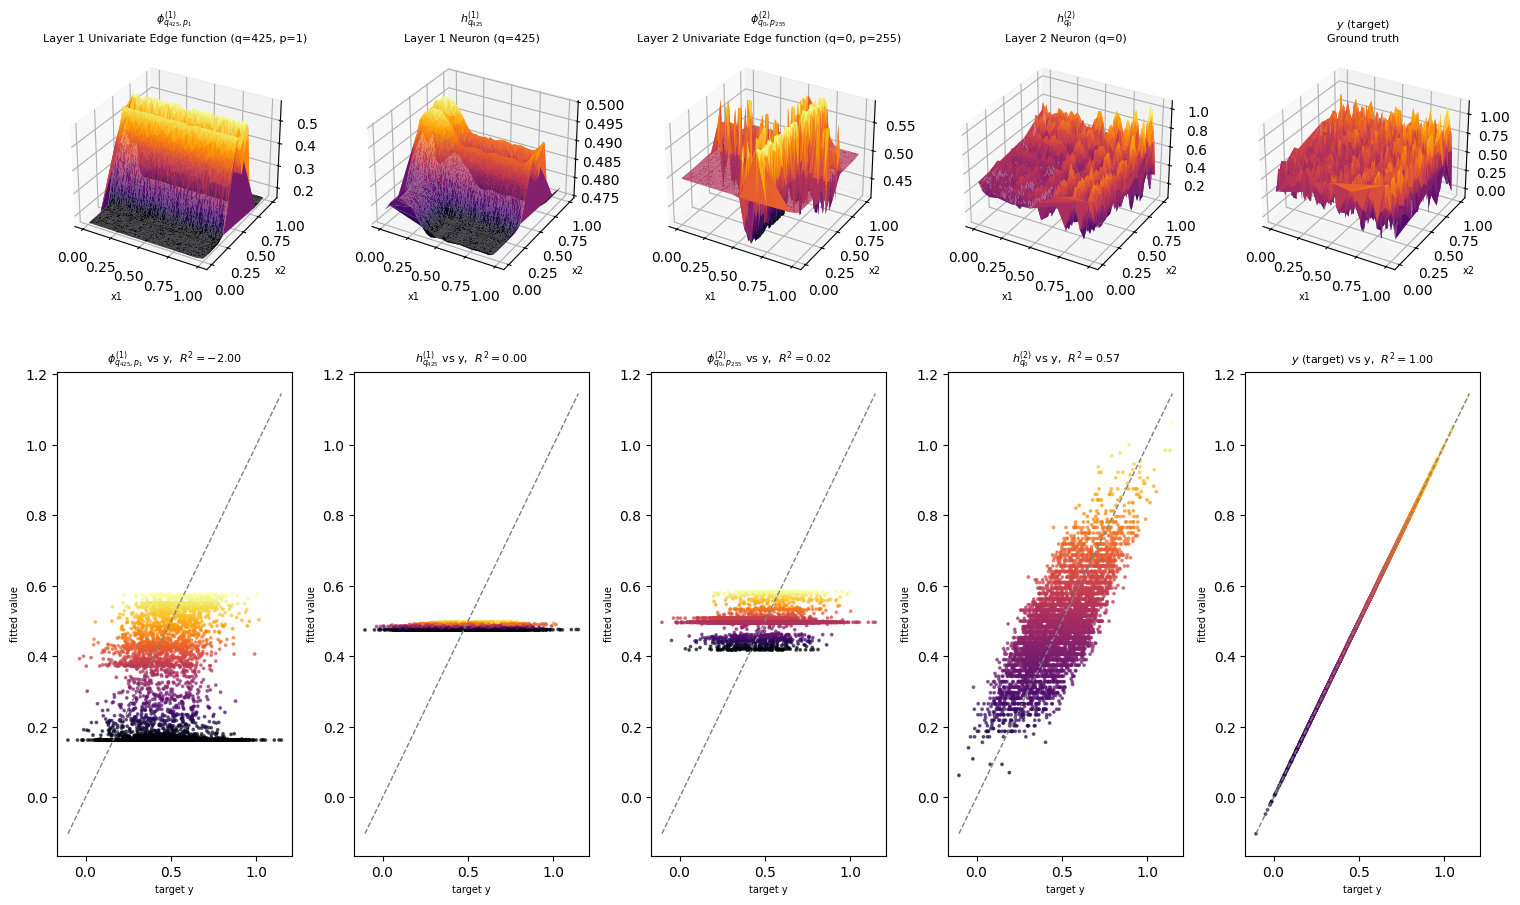

In [24]:
tf2_sgkan_layer_swim_configs = [
    {"layer_width": 500, "num_inducing": 25, "pair_selection_strategy": "swim", "alpha_edge": 0.1, "alpha_neuron": 0,
     "max_local_points": 1000, "kernel_type": "periodic", "seed": random_seed, "sigma_scale": 1},
    {"layer_width": 1, "num_inducing": 25, "pair_selection_strategy": "swim", "alpha_edge": 0.1, "alpha_neuron": 0,
     "max_local_points": 1000, "kernel_type": "periodic", "seed": random_seed, "sigma_scale": 1},
]
# A stage item in stages list consists of (layer_idx, phi[q, p, :] edge function results, layer_output) 
tf2_sgkan_stages, tf2_sgkan_ytrain_hat, tf2_sgkan_layer_neurons = sgkan_model.build_sgkan_stack(tf2_x_train, tf2_y_train, tf2_sgkan_layer_swim_configs)
print("TF2 SGKAN train R2:", r2_score(tf2_y_train, tf2_sgkan_ytrain_hat))

visualize.plot_model_stages(tf2_x_train, tf2_y_train, tf2_sgkan_stages, block_idx="random", seed=0)

In [25]:
tf2_sgkan_model = sgkan_model.SGKANModel(tf2_sgkan_layer_swim_configs).fit(tf2_x_train, tf2_y_train)

tf2_sgkan_results = em.evaluate(
    tf2_sgkan_model, tf2_x_train, tf2_y_train, tf2_x_test, tf2_y_test
)
em.print_results(tf2_sgkan_results)

[fit_layer] pair_selection_strategy = 'swim' (layer_width=500, D_in=2)
[fit_layer] local-window method counts over 1000 edges: {'interval_capped': 541, 'interval': 457, 'knn_fallback': 2}
[fit_layer] pair_selection_strategy = 'swim' (layer_width=1, D_in=500)
[fit_layer] local-window method counts over 500 edges: {'interval_capped': 412, 'interval': 88}
[SGKANModel.fit] Total fit duration: 6.5098s
Metric          Train                Test                
-------------------------------------------------------
MAE             9.580616e-02         4.246425e-02        
RMSE            1.134335e-01         5.770756e-02        
-------------------------------------------------------
Inference (s)   2.979388             6.183094            


### Optuna - Parameter Search

Find the best layer configuration for TF2 dataset.

In [26]:
tf2_result = sps.study_optuna_sgkan(
    "tf2", tf2_x_train, tf2_y_train, tf2_x_test, tf2_y_test,
    n_trials=375
)

Results found for tf2. Loading from data/tf2_sgkan_optuna_search.csv
Best Validation RMSE:   0.121462185834902
Best Test RMSE:          0.065457109784369
Best layer_width:        250
Best num_inducing:       100
Best alpha_edge:         1.000e-01
Best alpha_neuron:       0.000e+00
Best kernel_type:        rbf

All 375 trials:
     number           value  params_layer_width  params_num_inducing  params_alpha_edge  params_alpha_neuron params_kernel_type        val_rmse     test_rmse
0         0    0.1331500893                1000                   50              0.001                    0             matern    0.1331500893           NaN
1         1    0.1677634379                1000                   25              1.000                    0           periodic    0.1677634379           NaN
2         2    0.1260517351                 500                   50             10.000                    0                rbf    0.1260517351           NaN
3         3    0.1330076947             

In [27]:
# Use best parameter configuration to fit an SGKAN model again
best_tf2_configs = tf2_result["layer_configs"]
best_tf2_configs

[{'layer_width': 250,
  'num_inducing': 100,
  'pair_selection_strategy': 'swim',
  'alpha_edge': 0.1,
  'alpha_neuron': 0.0,
  'max_local_points': 1000,
  'kernel_type': 'rbf',
  'seed': 0,
  'sigma_scale': 1},
 {'layer_width': 1,
  'num_inducing': 100,
  'pair_selection_strategy': 'swim',
  'alpha_edge': 0.1,
  'alpha_neuron': 0.0,
  'max_local_points': 1000,
  'kernel_type': 'rbf',
  'seed': 0,
  'sigma_scale': 1}]

In [28]:
tf2_sgkan_optuna_df = pd.read_csv("data/tf2_sgkan_optuna_search.csv")
tf2_sgkan_optuna_df.sort_values("val_rmse").head(5)

,number,value,datetime_start,datetime_complete,duration,params_alpha_edge,params_alpha_neuron,params_kernel_type,params_layer_width,params_num_inducing,...,fit_duration_sec,kernel_type,user_attrs_layer_width,user_attrs_num_inducing,sigma_scale,val_rmse,system_attrs_grid_id,system_attrs_search_space,state,test_rmse
115,115,0.1214621858,2026-07-30 13:12:57.944953,2026-07-30 13:13:06.997633,9.052680,0.1,0,rbf,250,100,...,8.411982958,rbf,250,100,1,0.1214621858,115,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,0.0654571098
246,246,0.1216569889,2026-07-30 13:34:33.540495,2026-07-30 13:34:37.166854,3.626359,1.0,0,rbf,250,50,...,3.353157667,rbf,250,50,1,0.1216569889,246,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,NaN
120,120,0.1217049351,2026-07-30 13:13:54.294561,2026-07-30 13:14:00.786360,6.491799,0.1,0,rbf,250,75,...,5.978215791,rbf,250,75,1,0.1217049351,120,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,NaN
211,211,0.1218751473,2026-07-30 13:29:12.211312,2026-07-30 13:29:16.414230,4.202918,0.1,0,rbf,250,50,...,3.832117083,rbf,250,50,1,0.1218751473,211,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,NaN
270,270,0.1219373378,2026-07-30 13:38:03.269720,2026-07-30 13:38:10.265227,6.995507,10.0,0,rbf,250,75,...,6.400599583,rbf,250,75,1,0.1219373378,270,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,NaN


In [29]:
best_tf2_sgkan_model = sgkan_model.SGKANModel(best_tf2_configs).fit(tf2_x_train, tf2_y_train)

best_tf2_sgkan_results = em.evaluate(
    best_tf2_sgkan_model, tf2_x_train, tf2_y_train, tf2_x_test, tf2_y_test
)
em.print_results(best_tf2_sgkan_results)

[fit_layer] pair_selection_strategy = 'swim' (layer_width=250, D_in=2)
[fit_layer] local-window method counts over 500 edges: {'interval_capped': 281, 'interval': 218, 'knn_fallback': 1}
[fit_layer] pair_selection_strategy = 'swim' (layer_width=1, D_in=250)
[fit_layer] local-window method counts over 250 edges: {'interval': 159, 'interval_capped': 90, 'knn_fallback': 1}
[SGKANModel.fit] Total fit duration: 8.1588s
Metric          Train                Test                
-------------------------------------------------------
MAE             1.045171e-01         4.890183e-02        
RMSE            1.246754e-01         6.545711e-02        
-------------------------------------------------------
Inference (s)   3.917192             10.462674           


In [30]:
# Try best parameter configuration but without SWIM (random projections) this time
# Aim is to see if using SWIM matters
random_best_tf2_configs = [{'layer_width': 250,
  'num_inducing': 100,
  'pair_selection_strategy': 'random',
  'alpha_edge': 0.1,
  'alpha_neuron': 0,
  'max_local_points': 1000,
  'kernel_type': 'rbf',
  'seed': 0,
  'sigma_scale': 1},
 {'layer_width': 1,
  'num_inducing': 100,
  'pair_selection_strategy': 'random',
  'alpha_edge': 0.1,
  'alpha_neuron': 0,
  'max_local_points': 1000,
  'kernel_type': 'rbf',
  'seed': 0,
  'sigma_scale': 1}]

In [31]:
random_best_tf2_sgkan_model = sgkan_model.SGKANModel(random_best_tf2_configs).fit(tf2_x_train, tf2_y_train)

random_best_tf2_sgkan_results = em.evaluate(
    random_best_tf2_sgkan_model, tf2_x_train, tf2_y_train, tf2_x_test, tf2_y_test
)
em.print_results(random_best_tf2_sgkan_results)

[fit_layer] pair_selection_strategy = 'random' (layer_width=250, D_in=2)
[fit_layer] local-window method counts over 500 edges: {'interval_capped': 306, 'interval': 193, 'knn_fallback': 1}
[fit_layer] pair_selection_strategy = 'random' (layer_width=1, D_in=250)
[fit_layer] local-window method counts over 250 edges: {'interval': 239, 'knn_fallback': 9, 'interval_capped': 2}
[SGKANModel.fit] Total fit duration: 15.3605s
Metric          Train                Test                
-------------------------------------------------------
MAE             1.093588e-01         6.088820e-02        
RMSE            1.312890e-01         8.346060e-02        
-------------------------------------------------------
Inference (s)   3.558252             8.494575            


### 50 seed results

Run the best SGKAN model 50 times with different random seeds to compute median and IQR of RMSE, matching the methodology from HKAN's paper for fair comparison. This statistical approach accounts for the randomness in pair selection and provides a robust measure of model performance variability.

In [32]:
tf2_50_runs_path = "data/tf2_sgkan_50_run_results.csv"

if os.path.exists(tf2_50_runs_path):
    tf2_50_runs_df = pd.read_csv("data/tf2_sgkan_50_run_results.csv")
else:
    tf2_50_runs = run_sgkan_seed_experiments(tf2_x_train, tf2_y_train, tf2_x_test, tf2_y_test, best_tf2_configs, n_runs=50)
    tf2_50_runs_df = create_export_seed_results(tf2_50_runs, "tf2_sgkan_50_run_results")
tf2_50_runs_df.head()

,seed,train_mae,train_rmse,train_inference_time_secs,test_mae,test_rmse,test_inference_time_secs
0,0,0.1045171186,0.1246753695,4.001534917,0.0489018328,0.0654571098,7.628399125
1,1,0.1019724497,0.1193520351,4.133137542,0.0330745742,0.0439851001,7.327495333
2,2,0.0990619060,0.1153351497,3.725227917,0.0264353562,0.0346322725,6.868375000
3,3,0.1033787412,0.1228216723,4.944981709,0.0440061329,0.0574762297,9.210933333
4,4,0.1056725827,0.1260939082,6.330977000,0.0499275127,0.0653199878,9.560935750


In [33]:
summarize_metrics(tf2_50_runs_df, "SGKAN SWIM")

{'model': 'SGKAN SWIM',
 'train_rmse_median': 0.1206361296018124,
 'train_rmse_iqr': 0.011160628132760975,
 'test_rmse_median': 0.05163804382270855,
 'test_rmse_iqr': 0.031067237858904154}

### Hypothesis 1

Increasing layer width (other parameters are constant) vs. RMSE for different models HKAN, SGKAN swim and SGKAN random

Compare how increasing the first layer width affects performance across SGKAN (SWIM), SGKAN (random), and HKAN. All other parameters stay fixed to isolate the width effect. The goal is to understand whether wider layers consistently improve predictions and if this trend differs between the algorithms.

In [34]:
# Best TF2 HKAN configuration from the paper
tf2_hkan_layer_configs = [
    dict(layer=0, n_vars_out=48, n_basis=17, centers="random", basis_fn=Tanh(s=22), expanding_base_regressor=Ridge(alpha=0.1)),
    dict(layer=1, n_vars_out=11, n_basis=21, centers="random_data_points", basis_fn=Softplus(s=18), expanding_base_regressor=Ridge(alpha=1)),
    dict(layer=2, n_vars_out=1, n_basis=1, centers="equally_spaced", basis_fn=Identity(), expanding_base_regressor=None),
]

In [35]:
tf2_hypothesis_1_path = "data/tf2_hypothesis_1_results_df.csv"

if os.path.exists(tf2_hypothesis_1_path):
    tf2_hypothesis_1_results_df = pd.read_csv("data/tf2_hypothesis_1_results_df.csv")
else:
    # Define layer widths
    layer_widths = [2, 10, 25, 50, 100, 250, 500, 750, 1000]

    # Results storage
    results = {
        'sgkan_swim': {'widths': [], 'train_rmse': [], 'test_rmse': []},
        'sgkan_random': {'widths': [], 'train_rmse': [], 'test_rmse': []},
        'hkan': {'widths': [], 'train_rmse': [], 'test_rmse': []}
    }

    # SGKAN with SWIM
    print("Testing SGKAN with SWIM pair selection...")
    for width in layer_widths:
        config = [c.copy() for c in best_tf2_configs]
        config[0]['layer_width'] = width
        model = sgkan_model.SGKANModel(config).fit(tf2_x_train, tf2_y_train)
        eval_results = em.evaluate(model, tf2_x_train, tf2_y_train, tf2_x_test, tf2_y_test)
        results['sgkan_swim']['widths'].append(width)
        results['sgkan_swim']['train_rmse'].append(eval_results['train']['rmse'])
        results['sgkan_swim']['test_rmse'].append(eval_results['test']['rmse'])
        print(f"  Width {width}: Train RMSE={eval_results['train']['rmse']:.6e}, Test RMSE={eval_results['test']['rmse']:.6e}")

    # SGKAN with random pair selection
    print("\nTesting SGKAN with random pair selection...")
    for width in layer_widths:
        config = [c.copy() for c in best_tf2_configs]
        config[0]['pair_selection_strategy'] = 'random'
        config[0]['layer_width'] = width
        config[1]['pair_selection_strategy'] = 'random'
        model = sgkan_model.SGKANModel(config).fit(tf2_x_train, tf2_y_train)
        eval_results = em.evaluate(model, tf2_x_train, tf2_y_train, tf2_x_test, tf2_y_test)
        results['sgkan_random']['widths'].append(width)
        results['sgkan_random']['train_rmse'].append(eval_results['train']['rmse'])
        results['sgkan_random']['test_rmse'].append(eval_results['test']['rmse'])
        print(f"  Width {width}: Train RMSE={eval_results['train']['rmse']:.6e}, Test RMSE={eval_results['test']['rmse']:.6e}")

    # HKAN with best config
    print("\nTesting HKAN...")
    for width in layer_widths:
        config = [c.copy() for c in tf2_hkan_layer_configs]
        config[0]['n_vars_out'] = width
        model = utils.build_hkan_model_from_configs(config, tqdm_disable=True)
        utils.fit_hkan(model, tf2_x_train, tf2_y_train)
        eval_results = em.evaluate(model, tf2_x_train, tf2_y_train, tf2_x_test, tf2_y_test)
        results['hkan']['widths'].append(width)
        results['hkan']['train_rmse'].append(eval_results['train']['rmse'])
        results['hkan']['test_rmse'].append(eval_results['test']['rmse'])
        print(f"  Width {width}: Train RMSE={eval_results['train']['rmse']:.6e}, Test RMSE={eval_results['test']['rmse']:.6e}")

    # Display results
    tf2_hypothesis_1_results_df = pd.DataFrame({
        'layer_width': layer_widths,
        'sgkan_swim_train_rmse': results['sgkan_swim']['train_rmse'],
        'sgkan_swim_test_rmse': results['sgkan_swim']['test_rmse'],
        'sgkan_random_train_rmse': results['sgkan_random']['train_rmse'],
        'sgkan_random_test_rmse': results['sgkan_random']['test_rmse'],
        'hkan_train_rmse': results['hkan']['train_rmse'],
        'hkan_test_rmse': results['hkan']['test_rmse']
    })
    tf2_hypothesis_1_results_df.to_csv("data/tf2_hypothesis_1_results_df.csv")

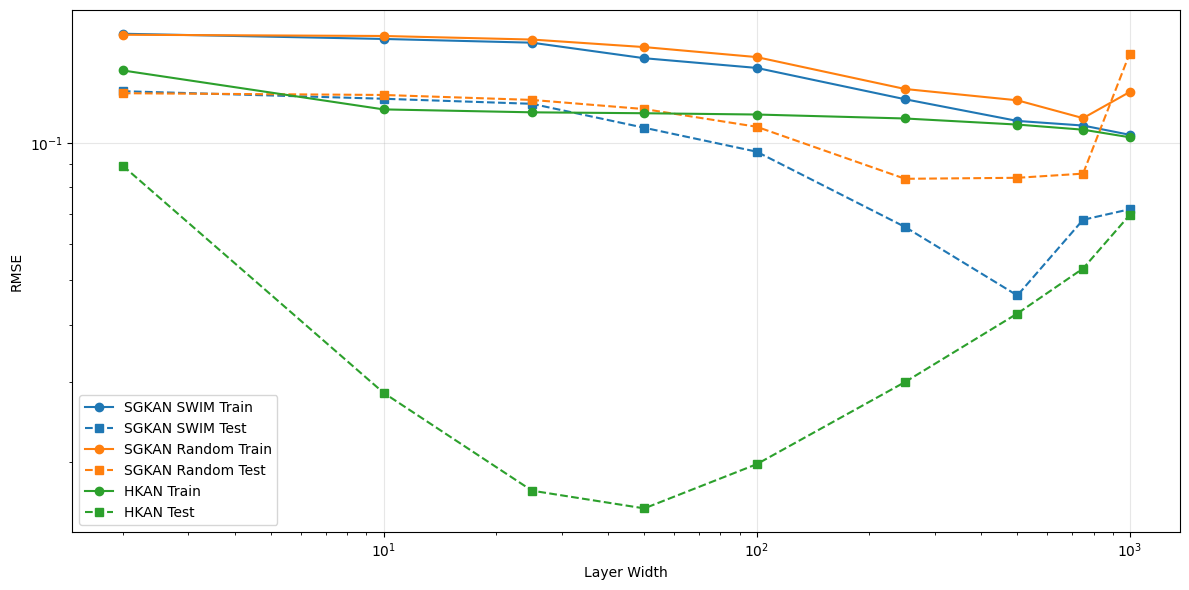

In [36]:
plot_hypothesis_1_results(tf2_hypothesis_1_results_df)

In [37]:
tf2_hypothesis_1_results_df

,Unnamed: 0,layer_width,sgkan_swim_train_rmse,sgkan_swim_test_rmse,sgkan_random_train_rmse,sgkan_random_test_rmse,hkan_train_rmse,hkan_test_rmse
0,0,2,0.1735073953,0.1298453405,0.1726209182,0.1285170328,0.1441738019,0.0891396800
1,1,10,0.1689981383,0.1249823204,0.1715421493,0.1273960757,0.1184487171,0.0283531908
2,2,25,0.1658427550,0.1218376309,0.1684925349,0.1242434888,0.1167138391,0.0173038155
3,3,50,0.1533436837,0.1079685559,0.1622015457,0.1186475307,0.1161748477,0.0158246039
4,4,100,0.1460309465,0.0956994466,0.1542319711,0.1085206224,0.1154300967,0.0197723613
5,5,250,0.1246753695,0.0654571098,0.1312889584,0.0834605952,0.1131410758,0.0299374375
6,6,500,0.1117585641,0.0463285705,0.1240073862,0.0838817028,0.1097191244,0.0422926197
7,7,750,0.1091909135,0.0678668000,0.1133357590,0.0856613655,0.1069295816,0.0530778551
8,8,1000,0.1042045475,0.0715694043,0.1293116260,0.1569520796,0.1029173073,0.0695114950


### Explore Feature importances and Layers

Examine how well each input feature is being captured by the first layer of the best model. This helps us understand which input dimensions are most important and how the model processes the input space.

In [38]:
best_tf2_configs

[{'layer_width': 250,
  'num_inducing': 100,
  'pair_selection_strategy': 'swim',
  'alpha_edge': 0.1,
  'alpha_neuron': 0.0,
  'max_local_points': 1000,
  'kernel_type': 'rbf',
  'seed': 0,
  'sigma_scale': 1},
 {'layer_width': 1,
  'num_inducing': 100,
  'pair_selection_strategy': 'swim',
  'alpha_edge': 0.1,
  'alpha_neuron': 0.0,
  'max_local_points': 1000,
  'kernel_type': 'rbf',
  'seed': 0,
  'sigma_scale': 1}]

[build_sgkan_stack] Layer 1: pair_selection_strategy = 'swim'
[fit_layer] pair_selection_strategy = 'swim' (layer_width=250, D_in=2)
[fit_layer] local-window method counts over 500 edges: {'interval_capped': 281, 'interval': 218, 'knn_fallback': 1}
[build_sgkan_stack] Layer 2: pair_selection_strategy = 'swim'
[fit_layer] pair_selection_strategy = 'swim' (layer_width=1, D_in=250)
[fit_layer] local-window method counts over 250 edges: {'interval': 159, 'interval_capped': 90, 'knn_fallback': 1}


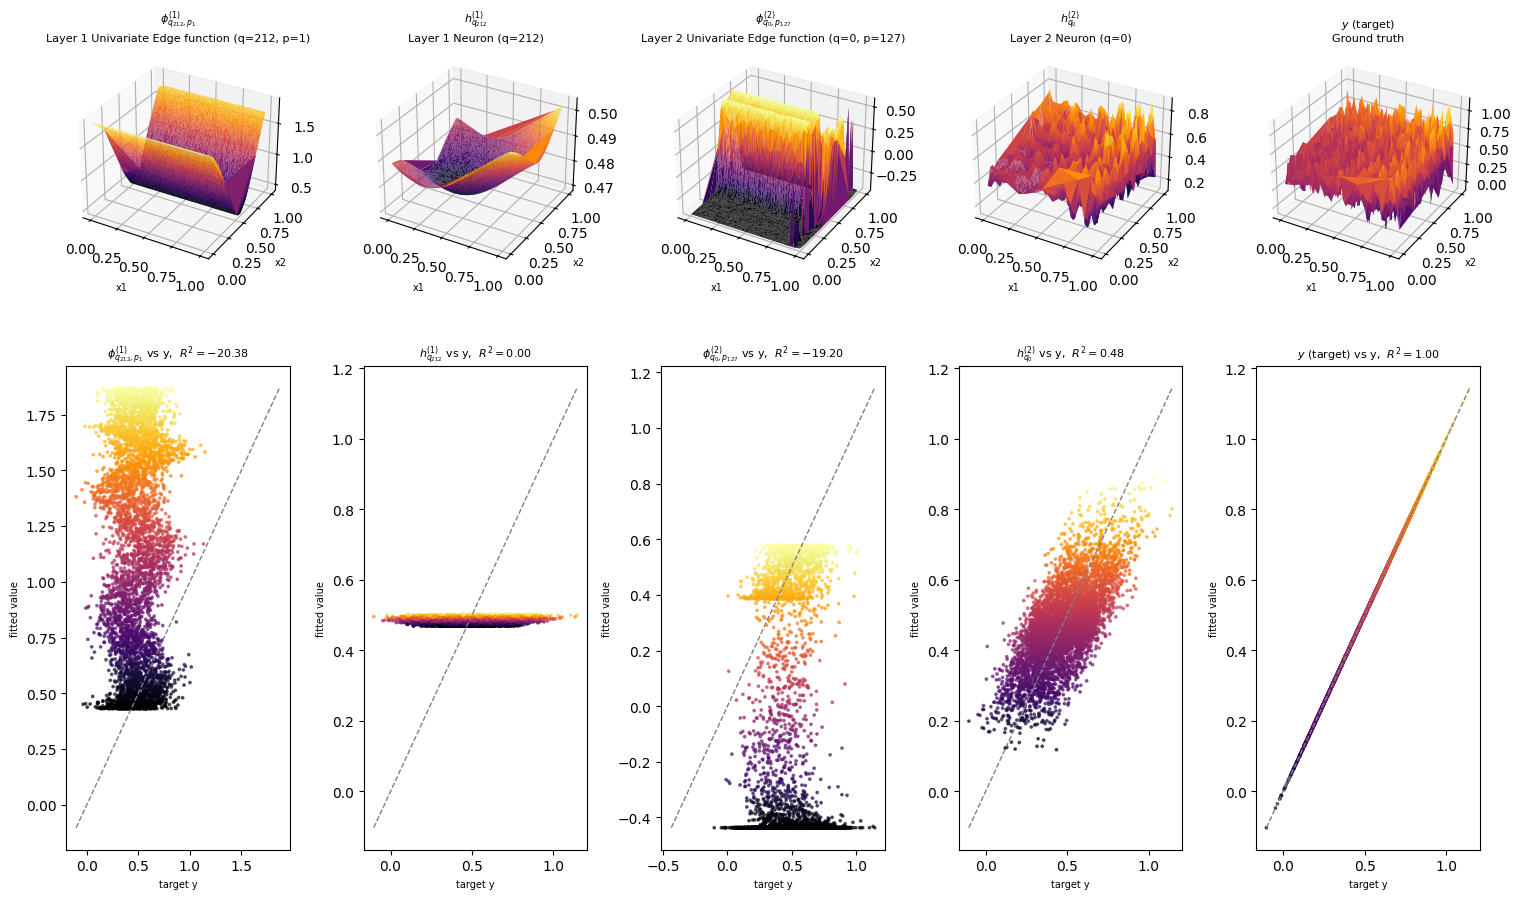

In [39]:
best_tf2_sgkan_stages, best_tf2_sgkan_ytrain_hat, best_tf2_sgkan_layer_neurons = sgkan_model.build_sgkan_stack(tf2_x_train, tf2_y_train, best_tf2_configs)
visualize.plot_model_stages(tf2_x_train, tf2_y_train, best_tf2_sgkan_stages, block_idx="random", seed=0)

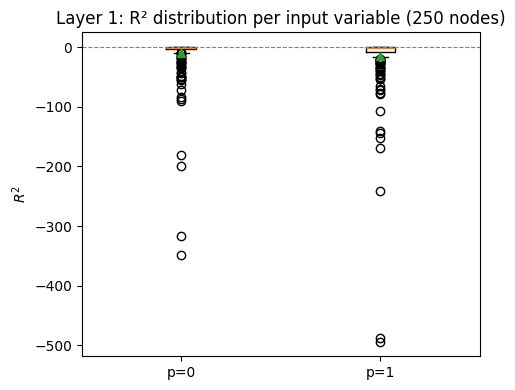

In [40]:
visualize.plot_first_layer_featurewise_r2_summary(best_tf2_sgkan_stages, tf2_y_train)

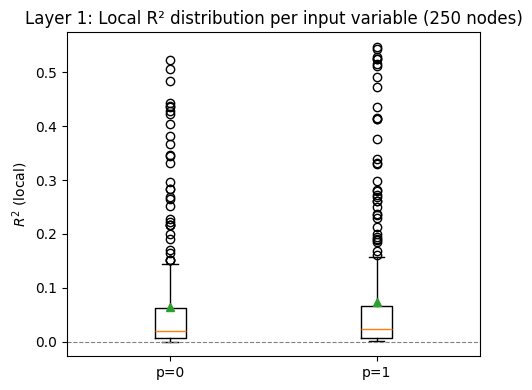

In [41]:
plot_first_layer_local_edge_r2_summary(best_tf2_sgkan_layer_neurons)

## TF3

For TF3, we'll find the best SGKAN configuration through hyperparameter optimization, then run a robustness test with 50 random seeds to compare against our HKAN reproduction, configured with the paper's best reported hyperparameters. We'll also explore how layer width impacts performance and which input features matter most.

### Sanity Check

Sanity check that the model runs without errors. This serves as a basic test before moving to optimization and comparison experiments.

[build_sgkan_stack] Layer 1: pair_selection_strategy = 'swim'
[fit_layer] pair_selection_strategy = 'swim' (layer_width=100, D_in=2)
[fit_layer] local-window method counts over 200 edges: {'interval': 94, 'interval_capped': 106}
[build_sgkan_stack] Layer 2: pair_selection_strategy = 'swim'
[fit_layer] pair_selection_strategy = 'swim' (layer_width=1, D_in=100)
[fit_layer] local-window method counts over 100 edges: {'interval_capped': 87, 'interval': 13}
TF3 SGKAN train R2: 0.9367658236272239


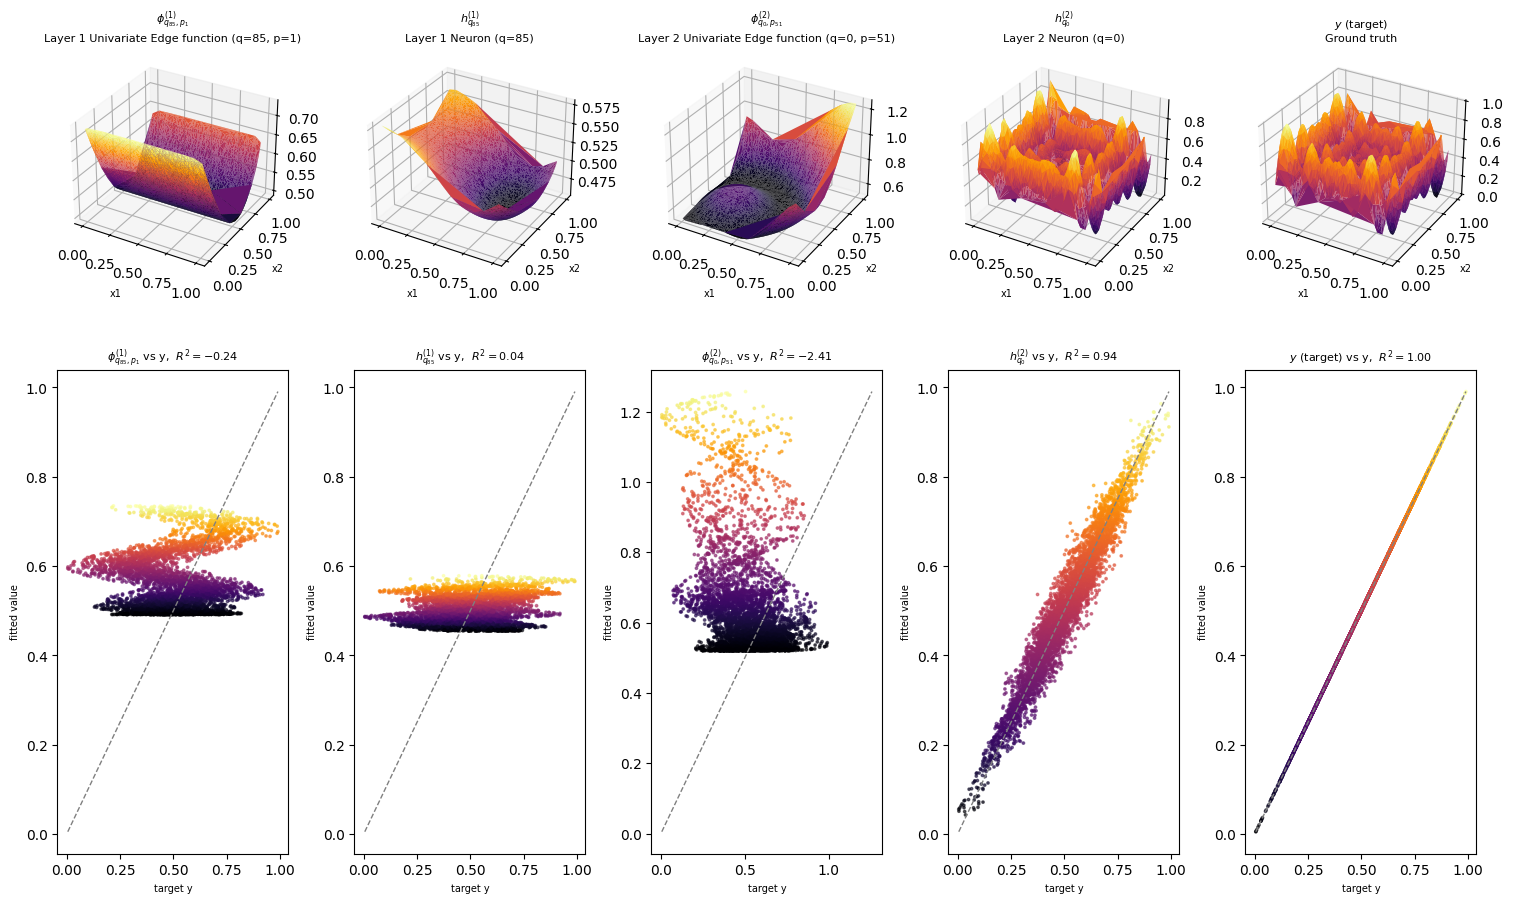

In [42]:
tf3_sgkan_layer_swim_configs = [
    {"layer_width": 100, "num_inducing": 75, "pair_selection_strategy": "swim", "alpha_edge": 1, "alpha_neuron": 0,
     "max_local_points": 1000, "kernel_type": "rbf", "seed": random_seed, "sigma_scale": 1},
    {"layer_width": 1, "num_inducing": 75, "pair_selection_strategy": "swim", "alpha_edge": 1, "alpha_neuron": 0,
     "max_local_points": 1000, "kernel_type": "rbf", "seed": random_seed, "sigma_scale": 1},
]
# A stage item in stages list consists of (layer_idx, phi[q, p, :] edge function results, layer_output) 
tf3_sgkan_stages, tf3_sgkan_ytrain_hat, tf3_sgkan_layer_neurons = sgkan_model.build_sgkan_stack(tf3_x_train, tf3_y_train, tf3_sgkan_layer_swim_configs)
print("TF3 SGKAN train R2:", r2_score(tf3_y_train, tf3_sgkan_ytrain_hat))

visualize.plot_model_stages(tf3_x_train, tf3_y_train, tf3_sgkan_stages, block_idx="random", seed=0)

In [43]:
tf3_sgkan_model = sgkan_model.SGKANModel(tf3_sgkan_layer_swim_configs).fit(tf3_x_train, tf3_y_train)

tf3_sgkan_results = em.evaluate(
    tf3_sgkan_model, tf3_x_train, tf3_y_train, tf3_x_test, tf3_y_test
)
em.print_results(tf3_sgkan_results)

[fit_layer] pair_selection_strategy = 'swim' (layer_width=100, D_in=2)
[fit_layer] local-window method counts over 200 edges: {'interval': 94, 'interval_capped': 106}
[fit_layer] pair_selection_strategy = 'swim' (layer_width=1, D_in=100)
[fit_layer] local-window method counts over 100 edges: {'interval_capped': 87, 'interval': 13}
[SGKANModel.fit] Total fit duration: 2.7293s
Metric          Train                Test                
-------------------------------------------------------
MAE             3.175018e-02         3.333701e-02        
RMSE            4.049184e-02         4.261182e-02        
-------------------------------------------------------
Inference (s)   1.009491             1.989156            


### Optuna - Parameter Search

Find the best layer configuration for TF3 dataset.

In [44]:
tf3_result = sps.study_optuna_sgkan(
    "tf3", tf3_x_train, tf3_y_train, tf3_x_test, tf3_y_test,
    n_trials=375
)

Results found for tf3. Loading from data/tf3_sgkan_optuna_search.csv
Best Validation RMSE:   0.001668977596210
Best Test RMSE:          0.002170478295980
Best layer_width:        1000
Best num_inducing:       10
Best alpha_edge:         1.000e+01
Best alpha_neuron:       0.000e+00
Best kernel_type:        matern

All 375 trials:
     number           value  params_layer_width  params_num_inducing  params_alpha_edge  params_alpha_neuron params_kernel_type        val_rmse     test_rmse
0         0    0.0022907176                1000                   50              0.001                    0             matern    0.0022907176           NaN
1         1    0.0326435391                1000                   25              1.000                    0           periodic    0.0326435391           NaN
2         2    0.0043878549                 500                   50             10.000                    0                rbf    0.0043878549           NaN
3         3    0.0255022457          

In [45]:
# Use best parameter configuration to fit an SGKAN model again
best_tf3_configs = tf3_result["layer_configs"]
best_tf3_configs

[{'layer_width': 1000,
  'num_inducing': 10,
  'pair_selection_strategy': 'swim',
  'alpha_edge': 10.0,
  'alpha_neuron': 0.0,
  'max_local_points': 1000,
  'kernel_type': 'matern',
  'seed': 0,
  'sigma_scale': 1},
 {'layer_width': 1,
  'num_inducing': 10,
  'pair_selection_strategy': 'swim',
  'alpha_edge': 10.0,
  'alpha_neuron': 0.0,
  'max_local_points': 1000,
  'kernel_type': 'matern',
  'seed': 0,
  'sigma_scale': 1}]

In [46]:
tf3_sgkan_optuna_df = pd.read_csv("data/tf3_sgkan_optuna_search.csv")
tf3_sgkan_optuna_df.sort_values("val_rmse").head(5)

,number,value,datetime_start,datetime_complete,duration,params_alpha_edge,params_alpha_neuron,params_kernel_type,params_layer_width,params_num_inducing,...,fit_duration_sec,kernel_type,user_attrs_layer_width,user_attrs_num_inducing,sigma_scale,val_rmse,system_attrs_grid_id,system_attrs_search_space,state,test_rmse
339,339,0.0016689776,2026-07-30 15:37:40.007731,2026-07-30 15:37:46.012116,6.004385,10.0,0,matern,1000,10,...,5.565641583,matern,1000,10,1,0.0016689776,339,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,0.0021704783
67,67,0.0017449706,2026-07-30 14:48:12.166727,2026-07-30 14:48:17.783904,5.617177,1.0,0,matern,1000,10,...,5.178453750,matern,1000,10,1,0.0017449706,67,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,NaN
77,77,0.0017738513,2026-07-30 14:50:04.729085,2026-07-30 14:50:14.845161,10.116076,1.0,0,matern,1000,25,...,9.284057625,matern,1000,25,1,0.0017738513,77,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,NaN
233,233,0.0018190916,2026-07-30 15:19:23.647921,2026-07-30 15:19:56.763238,33.115317,10.0,0,matern,1000,75,...,30.705199375,matern,1000,75,1,0.0018190916,233,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,NaN
95,95,0.0018397693,2026-07-30 14:53:56.748026,2026-07-30 14:54:41.916081,45.168055,10.0,0,matern,1000,100,...,41.488965417,matern,1000,100,1,0.0018397693,95,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,NaN


In [47]:
best_tf3_sgkan_model = sgkan_model.SGKANModel(best_tf3_configs).fit(tf3_x_train, tf3_y_train)

best_tf3_sgkan_results = em.evaluate(
    best_tf3_sgkan_model, tf3_x_train, tf3_y_train, tf3_x_test, tf3_y_test
)
em.print_results(best_tf3_sgkan_results)

[fit_layer] pair_selection_strategy = 'swim' (layer_width=1000, D_in=2)
[fit_layer] local-window method counts over 2000 edges: {'interval': 937, 'interval_capped': 1063}
[fit_layer] pair_selection_strategy = 'swim' (layer_width=1, D_in=1000)
[fit_layer] local-window method counts over 1000 edges: {'interval_capped': 774, 'interval': 226}
[SGKANModel.fit] Total fit duration: 6.0788s
Metric          Train                Test                
-------------------------------------------------------
MAE             1.340852e-03         1.579185e-03        
RMSE            1.760732e-03         2.170478e-03        
-------------------------------------------------------
Inference (s)   2.017408             4.072172            


In [48]:
# Try best parameter configuration but without SWIM (random projections) this time
# Aim is to see if using SWIM matters
random_best_tf3_configs = [{'layer_width': 1000,
  'num_inducing': 10,
  'pair_selection_strategy': 'random',
  'alpha_edge': 10,
  'alpha_neuron': 0,
  'max_local_points': 1000,
  'kernel_type': 'matern',
  'seed': 0,
  'sigma_scale': 1},
 {'layer_width': 1,
  'num_inducing': 10,
  'pair_selection_strategy': 'random',
  'alpha_edge': 10,
  'alpha_neuron': 0,
  'max_local_points': 1000,
  'kernel_type': 'matern',
  'seed': 0,
  'sigma_scale': 1}]

In [49]:
random_best_tf3_sgkan_model = sgkan_model.SGKANModel(random_best_tf3_configs).fit(tf3_x_train, tf3_y_train)

random_best_tf3_sgkan_results = em.evaluate(
    random_best_tf3_sgkan_model, tf3_x_train, tf3_y_train, tf3_x_test, tf3_y_test
)
em.print_results(random_best_tf3_sgkan_results)

[fit_layer] pair_selection_strategy = 'random' (layer_width=1000, D_in=2)
[fit_layer] local-window method counts over 2000 edges: {'interval_capped': 1293, 'interval': 705, 'knn_fallback': 2}
[fit_layer] pair_selection_strategy = 'random' (layer_width=1, D_in=1000)
[fit_layer] local-window method counts over 1000 edges: {'interval': 231, 'interval_capped': 767, 'knn_fallback': 2}
[SGKANModel.fit] Total fit duration: 6.4212s
Metric          Train                Test                
-------------------------------------------------------
MAE             8.806981e-04         1.166765e-03        
RMSE            1.356601e-03         1.882493e-03        
-------------------------------------------------------
Inference (s)   2.060700             4.179296            


### 50 seed results

Run the best SGKAN model 50 times with different random seeds to compute median and IQR of RMSE, matching the methodology from HKAN's paper for fair comparison. This statistical approach accounts for the randomness in pair selection and provides a robust measure of model performance variability.

In [50]:
tf3_50_runs_path = "data/tf3_sgkan_50_run_results.csv"

if os.path.exists(tf3_50_runs_path):
    tf3_50_runs_df = pd.read_csv("data/tf3_sgkan_50_run_results.csv") 
else:
    tf3_50_runs = run_sgkan_seed_experiments(tf3_x_train, tf3_y_train, tf3_x_test, tf3_y_test, best_tf3_configs, n_runs=50)
    tf3_50_runs_df = create_export_seed_results(tf3_50_runs, "tf3_sgkan_50_run_results")

tf3_50_runs_df.head()

,seed,train_mae,train_rmse,train_inference_time_secs,test_mae,test_rmse,test_inference_time_secs
0,0,0.0013408517,0.0017607324,1.945098500,0.0015791847,0.0021704783,3.972601875
1,1,0.0008438658,0.0012670040,2.086786250,0.0011194534,0.0017977428,3.639279208
2,2,0.0156496872,0.0189551547,2.062441875,0.0178333967,0.0221828768,4.002830833
3,3,0.0014847114,0.0020794983,1.896135500,0.0020760345,0.0032585836,3.729100500
4,4,0.0009899318,0.0015321760,1.933104833,0.0012902115,0.0020784130,3.559153375


In [51]:
summarize_metrics(tf3_50_runs_df, "SGKAN SWIM")

{'model': 'SGKAN SWIM',
 'train_rmse_median': 0.00155556693586705,
 'train_rmse_iqr': 0.00041061731270487485,
 'test_rmse_median': 0.0021626578165526,
 'test_rmse_iqr': 0.0005834166828790003}

### Hypothesis 1

Increasing layer width (other parameters are constant) vs. RMSE for different models HKAN, SGKAN swim and SGKAN random

Compare how increasing the first layer width affects performance across SGKAN (SWIM), SGKAN (random), and HKAN. All other parameters stay fixed to isolate the width effect. The goal is to understand whether wider layers consistently improve predictions and if this trend differs between the algorithms.

In [52]:
# Best TF3 HKAN configuration from the paper
tf3_hkan_layer_configs = [
    dict(layer=0, n_vars_out=924, n_basis=39, centers="random", basis_fn=Tanh(s=50), expanding_base_regressor=Ridge(alpha=0.001)),
    dict(layer=1, n_vars_out=1, n_basis=1, centers="equally_spaced", basis_fn=Identity(), expanding_base_regressor=None),
]

In [53]:
tf3_hypothesis_1_path = "data/tf3_hypothesis_1_results_df.csv"

if os.path.exists(tf3_hypothesis_1_path):
    tf3_hypothesis_1_results_df = pd.read_csv("data/tf3_hypothesis_1_results_df.csv")
else:
    # Define layer widths
    layer_widths = [2, 10, 25, 50, 100, 250, 500, 750, 1000]

    # Results storage
    results = {
        'sgkan_swim': {'widths': [], 'train_rmse': [], 'test_rmse': []},
        'sgkan_random': {'widths': [], 'train_rmse': [], 'test_rmse': []},
        'hkan': {'widths': [], 'train_rmse': [], 'test_rmse': []}
    }

    # SGKAN with SWIM
    print("Testing SGKAN with SWIM pair selection...")
    for width in layer_widths:
        config = [c.copy() for c in best_tf3_configs]
        config[0]['layer_width'] = width
        model = sgkan_model.SGKANModel(config).fit(tf3_x_train, tf3_y_train)
        eval_results = em.evaluate(model, tf3_x_train, tf3_y_train, tf3_x_test, tf3_y_test)
        results['sgkan_swim']['widths'].append(width)
        results['sgkan_swim']['train_rmse'].append(eval_results['train']['rmse'])
        results['sgkan_swim']['test_rmse'].append(eval_results['test']['rmse'])
        print(f"  Width {width}: Train RMSE={eval_results['train']['rmse']:.6e}, Test RMSE={eval_results['test']['rmse']:.6e}")

    # SGKAN with random pair selection
    print("\nTesting SGKAN with random pair selection...")
    for width in layer_widths:
        config = [c.copy() for c in best_tf3_configs]
        config[0]['pair_selection_strategy'] = 'random'
        config[0]['layer_width'] = width
        config[1]['pair_selection_strategy'] = 'random'
        model = sgkan_model.SGKANModel(config).fit(tf3_x_train, tf3_y_train)
        eval_results = em.evaluate(model, tf3_x_train, tf3_y_train, tf3_x_test, tf3_y_test)
        results['sgkan_random']['widths'].append(width)
        results['sgkan_random']['train_rmse'].append(eval_results['train']['rmse'])
        results['sgkan_random']['test_rmse'].append(eval_results['test']['rmse'])
        print(f"  Width {width}: Train RMSE={eval_results['train']['rmse']:.6e}, Test RMSE={eval_results['test']['rmse']:.6e}")

    # HKAN with best config
    print("\nTesting HKAN...")
    for width in layer_widths:
        config = [c.copy() for c in tf3_hkan_layer_configs]
        config[0]['n_vars_out'] = width
        model = utils.build_hkan_model_from_configs(config, tqdm_disable=True)
        utils.fit_hkan(model, tf3_x_train, tf3_y_train)
        eval_results = em.evaluate(model, tf3_x_train, tf3_y_train, tf3_x_test, tf3_y_test)
        results['hkan']['widths'].append(width)
        results['hkan']['train_rmse'].append(eval_results['train']['rmse'])
        results['hkan']['test_rmse'].append(eval_results['test']['rmse'])
        print(f"  Width {width}: Train RMSE={eval_results['train']['rmse']:.6e}, Test RMSE={eval_results['test']['rmse']:.6e}")

    # Display results
    tf3_hypothesis_1_results_df = pd.DataFrame({
        'layer_width': layer_widths,
        'sgkan_swim_train_rmse': results['sgkan_swim']['train_rmse'],
        'sgkan_swim_test_rmse': results['sgkan_swim']['test_rmse'],
        'sgkan_random_train_rmse': results['sgkan_random']['train_rmse'],
        'sgkan_random_test_rmse': results['sgkan_random']['test_rmse'],
        'hkan_train_rmse': results['hkan']['train_rmse'],
        'hkan_test_rmse': results['hkan']['test_rmse']
    })
    tf3_hypothesis_1_results_df.to_csv("data/tf3_hypothesis_1_results_df.csv")

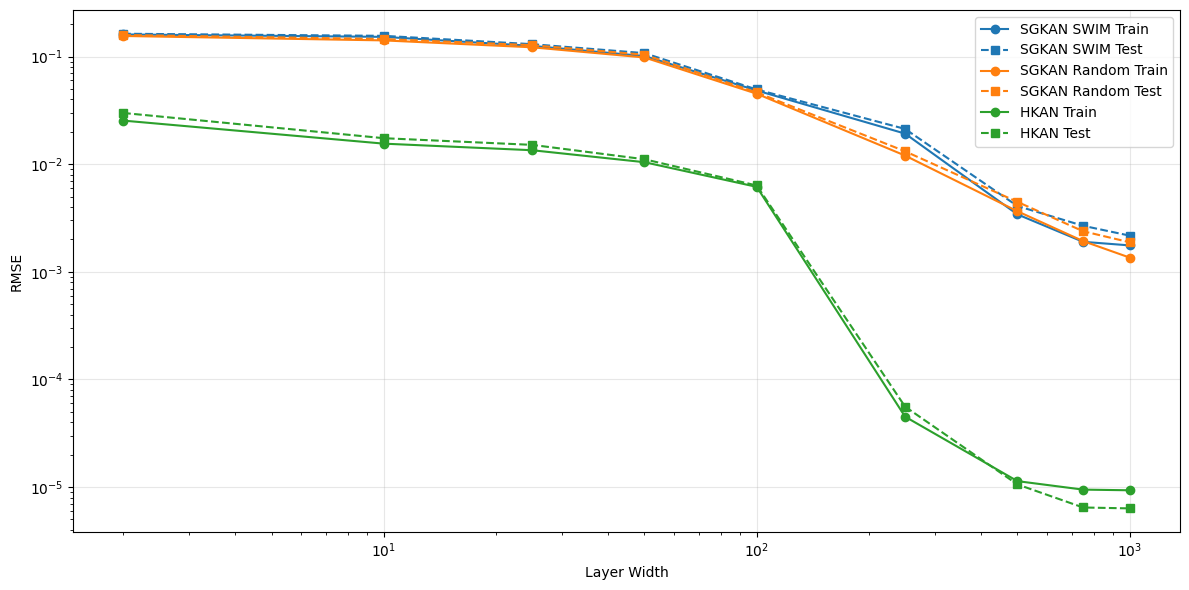

In [54]:
plot_hypothesis_1_results(tf3_hypothesis_1_results_df)

In [55]:
tf3_hypothesis_1_results_df

,Unnamed: 0,layer_width,sgkan_swim_train_rmse,sgkan_swim_test_rmse,sgkan_random_train_rmse,sgkan_random_test_rmse,hkan_train_rmse,hkan_test_rmse
0,0,2,0.1607070269,0.1631478059,0.1555060661,0.1588059470,0.0254437635,0.0299561558
1,1,10,0.1525498934,0.1559973313,0.1414634131,0.1456959661,0.0155332018,0.0174524709
2,2,25,0.1257850493,0.1304583399,0.1220446515,0.1277331280,0.0134927251,0.0151305041
3,3,50,0.1011589638,0.1076917243,0.0981748347,0.1041191362,0.0104431881,0.0111224210
4,4,100,0.0484372907,0.0494932380,0.0451894517,0.0464672820,0.0061614312,0.0063448666
5,5,250,0.0192444009,0.0212652936,0.0120295672,0.0131761758,0.0000450629,0.0000558287
6,6,500,0.0034194201,0.0040901943,0.0036556830,0.0044700277,0.0000113563,0.0000105849
7,7,750,0.0019015525,0.0026794724,0.0019312415,0.0023843746,0.0000094712,0.0000064619
8,8,1000,0.0017607324,0.0021704783,0.0013566009,0.0018824934,0.0000093367,0.0000063378


### Explore Feature importances and Layers

Examine how well each input feature is being captured by the first layer of the best model. This helps us understand which input dimensions are most important and how the model processes the input space.

In [56]:
best_tf3_configs

[{'layer_width': 1000,
  'num_inducing': 10,
  'pair_selection_strategy': 'swim',
  'alpha_edge': 10.0,
  'alpha_neuron': 0.0,
  'max_local_points': 1000,
  'kernel_type': 'matern',
  'seed': 0,
  'sigma_scale': 1},
 {'layer_width': 1,
  'num_inducing': 10,
  'pair_selection_strategy': 'swim',
  'alpha_edge': 10.0,
  'alpha_neuron': 0.0,
  'max_local_points': 1000,
  'kernel_type': 'matern',
  'seed': 0,
  'sigma_scale': 1}]

[build_sgkan_stack] Layer 1: pair_selection_strategy = 'swim'
[fit_layer] pair_selection_strategy = 'swim' (layer_width=1000, D_in=2)
[fit_layer] local-window method counts over 2000 edges: {'interval': 937, 'interval_capped': 1063}
[build_sgkan_stack] Layer 2: pair_selection_strategy = 'swim'
[fit_layer] pair_selection_strategy = 'swim' (layer_width=1, D_in=1000)
[fit_layer] local-window method counts over 1000 edges: {'interval_capped': 774, 'interval': 226}


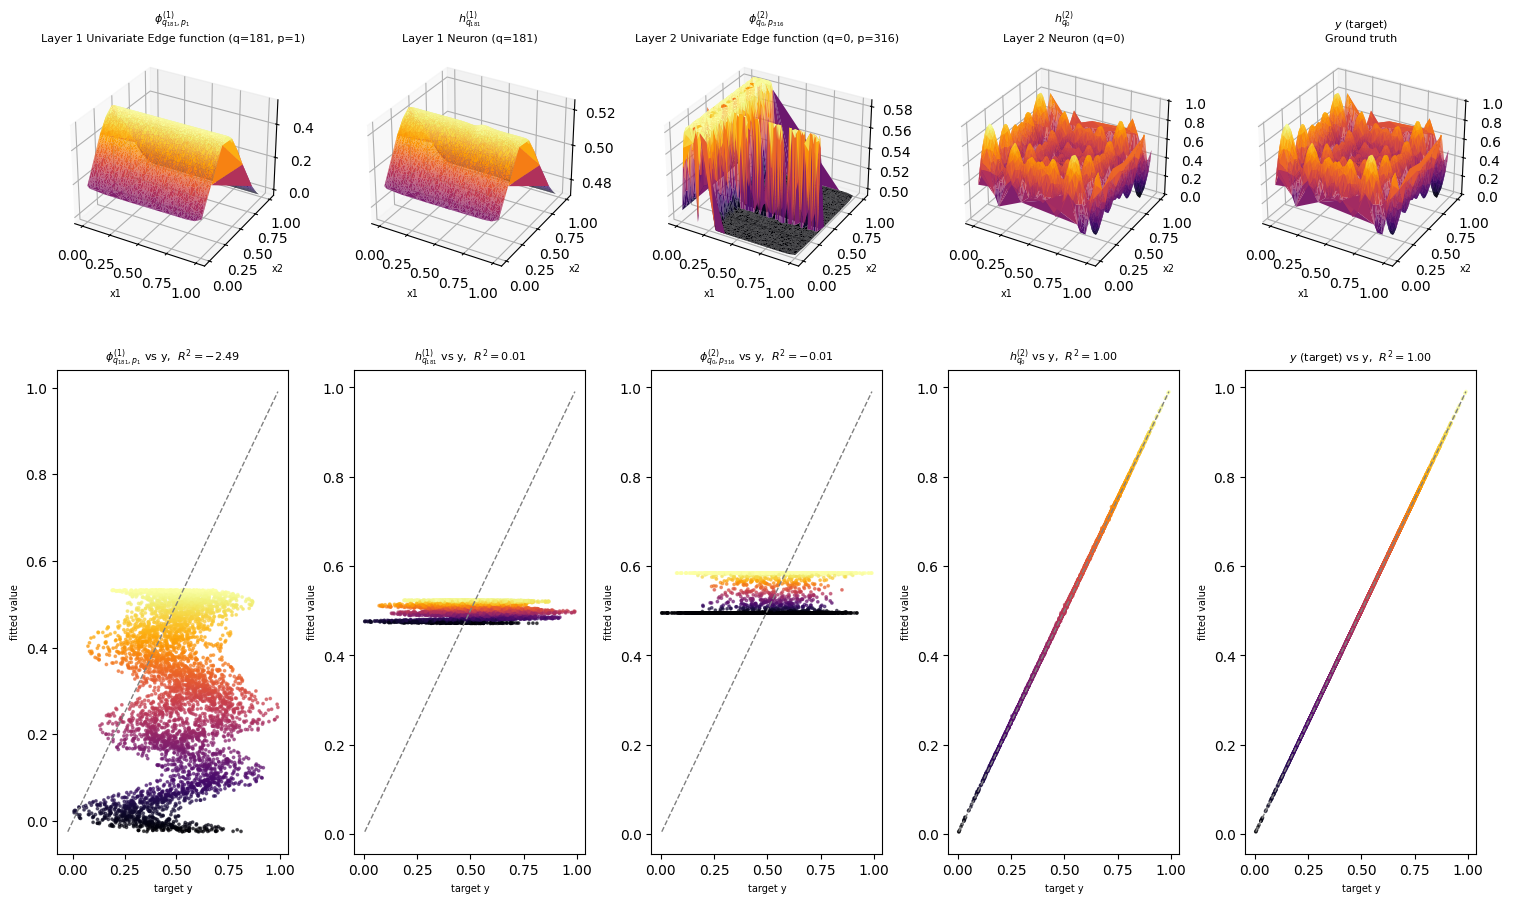

In [57]:
best_tf3_sgkan_stages, best_tf3_sgkan_ytrain_hat, best_tf3_sgkan_layer_neurons = sgkan_model.build_sgkan_stack(tf3_x_train, tf3_y_train, best_tf3_configs)
visualize.plot_model_stages(tf3_x_train, tf3_y_train, best_tf3_sgkan_stages, block_idx="random")

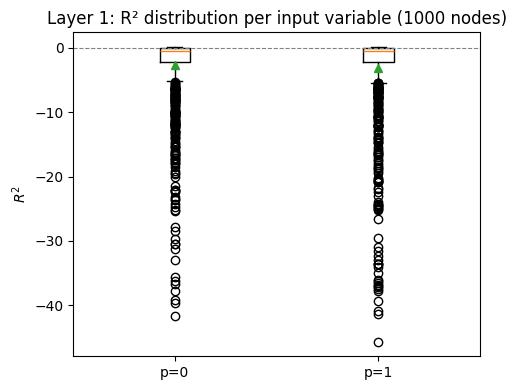

In [58]:
visualize.plot_first_layer_featurewise_r2_summary(best_tf3_sgkan_stages, tf3_y_train)

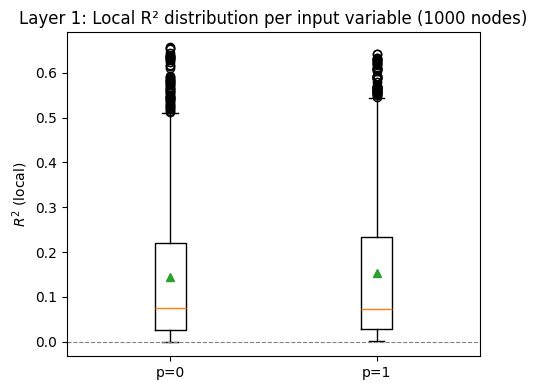

In [59]:
plot_first_layer_local_edge_r2_summary(best_tf3_sgkan_layer_neurons)

## TF4

For TF4, we'll find the best SGKAN configuration through hyperparameter optimization, then run a robustness test with 50 random seeds to compare against our HKAN reproduction, configured with the paper's best reported hyperparameters. We'll also explore how layer width impacts performance and which input features matter most.

### Sanity Check

Sanity check that the model runs without errors. This serves as a basic test before moving to optimization and comparison experiments.

In [ ]:
tf4_sgkan_layer_swim_configs = [
    {"layer_width": 100, "num_inducing": 75, "pair_selection_strategy": "swim", "alpha_edge": 1, "alpha_neuron": 0,
     "max_local_points": 1000, "kernel_type": "rbf", "seed": random_seed, "sigma_scale": 1},
    {"layer_width": 1, "num_inducing": 75, "pair_selection_strategy": "swim", "alpha_edge": 1, "alpha_neuron": 0,
     "max_local_points": 1000, "kernel_type": "rbf", "seed": random_seed, "sigma_scale": 1},
]
# A stage item in stages list consists of (layer_idx, phi[q, p, :] edge function results, layer_output) 
tf4_sgkan_stages, tf4_sgkan_ytrain_hat, tf4_sgkan_layer_neurons = sgkan_model.build_sgkan_stack(tf4_x_train, tf4_y_train, tf4_sgkan_layer_swim_configs)
print("TF4 SGKAN train R2:", r2_score(tf4_y_train, tf4_sgkan_ytrain_hat))

visualize.plot_model_stages(tf4_x_train, tf4_y_train, tf4_sgkan_stages, block_idx="random", seed=0)

In [ ]:
tf4_sgkan_model = sgkan_model.SGKANModel(tf4_sgkan_layer_swim_configs).fit(tf4_x_train, tf4_y_train)

tf4_sgkan_results = em.evaluate(
    tf4_sgkan_model, tf4_x_train, tf4_y_train, tf4_x_test, tf4_y_test
)
em.print_results(tf4_sgkan_results)

### Optuna - Parameter Search

Find the best layer configuration for TF4 dataset.

In [ ]:
tf4_result = sps.study_optuna_sgkan(
    "tf4", tf4_x_train, tf4_y_train, tf4_x_test, tf4_y_test,
    n_trials=375
)

In [ ]:
# Use best parameter configuration to fit an SGKAN model again
best_tf4_configs = tf4_result["layer_configs"]
best_tf4_configs

In [ ]:
tf4_sgkan_optuna_df = pd.read_csv("data/tf4_sgkan_optuna_search.csv")
tf4_sgkan_optuna_df.sort_values("val_rmse").head(5)

In [ ]:
best_tf4_configs = [
    {'layer_width': 1000,
    'num_inducing': 50,
    'pair_selection_strategy': 'swim',
    'alpha_edge': 0.1,
    'alpha_neuron': 0.0,
    'max_local_points': 1000,
    'kernel_type': 'rbf',
    'seed': 0,
    'sigma_scale': 1},
    {'layer_width': 1,
    'num_inducing': 50,
    'pair_selection_strategy': 'swim',
    'alpha_edge': 0.1,
    'alpha_neuron': 0.0,
    'max_local_points': 1000,
    'kernel_type': 'rbf',
    'seed': 0,
    'sigma_scale': 1
}]

best_tf4_sgkan_model = sgkan_model.SGKANModel(best_tf4_configs).fit(tf4_x_train, tf4_y_train)

best_tf4_sgkan_results = em.evaluate(
    best_tf4_sgkan_model, tf4_x_train, tf4_y_train, tf4_x_test, tf4_y_test
)
em.print_results(best_tf4_sgkan_results)

In [ ]:
# Try best parameter configuration but without SWIM (random projections) this time
# Aim is to see if using SWIM matters
random_best_tf4_configs = [
    {'layer_width': 1000,
    'num_inducing': 50,
    'pair_selection_strategy': 'random',
    'alpha_edge': 0.1,
    'alpha_neuron': 0.0,
    'max_local_points': 1000,
    'kernel_type': 'rbf',
    'seed': 0,
    'sigma_scale': 1},
    {'layer_width': 1,
    'num_inducing': 50,
    'pair_selection_strategy': 'random',
    'alpha_edge': 0.1,
    'alpha_neuron': 0.0,
    'max_local_points': 1000,
    'kernel_type': 'rbf',
    'seed': 0,
    'sigma_scale': 1
}]

In [ ]:
random_best_tf4_sgkan_model = sgkan_model.SGKANModel(random_best_tf4_configs).fit(tf4_x_train, tf4_y_train)

random_best_tf4_sgkan_results = em.evaluate(
    random_best_tf4_sgkan_model, tf4_x_train, tf4_y_train, tf4_x_test, tf4_y_test
)
em.print_results(random_best_tf4_sgkan_results)

### 50 seed results

Run the best SGKAN model 50 times with different random seeds to compute median and IQR of RMSE, matching the methodology from HKAN's paper for fair comparison. This statistical approach accounts for the randomness in pair selection and provides a robust measure of model performance variability.

In [ ]:
# tf4_50_runs = run_sgkan_seed_experiments(tf4_x_train, tf4_y_train, tf4_x_test, tf4_y_test, best_tf4_configs, n_runs=50)
# tf4_50_runs_df = create_export_seed_results(tf4_50_runs, "tf4_sgkan_50_run_results")
tf4_50_runs_df = pd.read_csv("data/tf4_sgkan_50_run_results.csv")
tf4_50_runs_df.head()

In [ ]:
summarize_metrics(tf4_50_runs_df, "SGKAN SWIM")

### Hypothesis 1

Increasing layer width (other parameters are constant) vs. RMSE for different models HKAN, SGKAN swim and SGKAN random

Compare how increasing the first layer width affects performance across SGKAN (SWIM), SGKAN (random), and HKAN. All other parameters stay fixed to isolate the width effect. The goal is to understand whether wider layers consistently improve predictions and if this trend differs between the algorithms.

In [ ]:
# Best TF4 HKAN configuration from the paper
tf4_hkan_layer_configs = [
    dict(layer=0, n_vars_out=932, n_basis=2, centers="random_data_points", basis_fn=Sigmoid(s=1), expanding_base_regressor=Ridge(alpha=0.1)),
    dict(layer=1, n_vars_out=1, n_basis=13, centers="random_data_points", basis_fn=Tanh(s=33), expanding_base_regressor=Ridge(alpha=10)),
]

In [ ]:
# # Define layer widths
# layer_widths = [2, 10, 25, 50, 100, 250, 500, 750, 1000]

# # Results storage
# results = {
#     'sgkan_swim': {'widths': [], 'train_rmse': [], 'test_rmse': []},
#     'sgkan_random': {'widths': [], 'train_rmse': [], 'test_rmse': []},
#     'hkan': {'widths': [], 'train_rmse': [], 'test_rmse': []}
# }

# # SGKAN with SWIM
# print("Testing SGKAN with SWIM pair selection...")
# for width in layer_widths:
#     config = [c.copy() for c in best_tf4_configs]
#     config[0]['layer_width'] = width
#     model = sgkan_model.SGKANModel(config).fit(tf4_x_train, tf4_y_train)
#     eval_results = em.evaluate(model, tf4_x_train, tf4_y_train, tf4_x_test, tf4_y_test)
#     results['sgkan_swim']['widths'].append(width)
#     results['sgkan_swim']['train_rmse'].append(eval_results['train']['rmse'])
#     results['sgkan_swim']['test_rmse'].append(eval_results['test']['rmse'])
#     print(f"  Width {width}: Train RMSE={eval_results['train']['rmse']:.6e}, Test RMSE={eval_results['test']['rmse']:.6e}")

# # SGKAN with random pair selection
# print("\nTesting SGKAN with random pair selection...")
# for width in layer_widths:
#     config = [c.copy() for c in best_tf4_configs]
#     config[0]['pair_selection_strategy'] = 'random'
#     config[0]['layer_width'] = width
#     config[1]['pair_selection_strategy'] = 'random'
#     model = sgkan_model.SGKANModel(config).fit(tf4_x_train, tf4_y_train)
#     eval_results = em.evaluate(model, tf4_x_train, tf4_y_train, tf4_x_test, tf4_y_test)
#     results['sgkan_random']['widths'].append(width)
#     results['sgkan_random']['train_rmse'].append(eval_results['train']['rmse'])
#     results['sgkan_random']['test_rmse'].append(eval_results['test']['rmse'])
#     print(f"  Width {width}: Train RMSE={eval_results['train']['rmse']:.6e}, Test RMSE={eval_results['test']['rmse']:.6e}")

# # HKAN with best config
# print("\nTesting HKAN...")
# for width in layer_widths:
#     config = [c.copy() for c in tf4_hkan_layer_configs]
#     config[0]['n_vars_out'] = width
#     model = utils.build_hkan_model_from_configs(config, tqdm_disable=True)
#     utils.fit_hkan(model, tf4_x_train, tf4_y_train)
#     eval_results = em.evaluate(model, tf4_x_train, tf4_y_train, tf4_x_test, tf4_y_test)
#     results['hkan']['widths'].append(width)
#     results['hkan']['train_rmse'].append(eval_results['train']['rmse'])
#     results['hkan']['test_rmse'].append(eval_results['test']['rmse'])
#     print(f"  Width {width}: Train RMSE={eval_results['train']['rmse']:.6e}, Test RMSE={eval_results['test']['rmse']:.6e}")

# # Display results
# tf4_hypothesis_1_results_df = pd.DataFrame({
#     'layer_width': layer_widths,
#     'sgkan_swim_train_rmse': results['sgkan_swim']['train_rmse'],
#     'sgkan_swim_test_rmse': results['sgkan_swim']['test_rmse'],
#     'sgkan_random_train_rmse': results['sgkan_random']['train_rmse'],
#     'sgkan_random_test_rmse': results['sgkan_random']['test_rmse'],
#     'hkan_train_rmse': results['hkan']['train_rmse'],
#     'hkan_test_rmse': results['hkan']['test_rmse']
# })
# tf4_hypothesis_1_results_df.to_csv("data/tf4_hypothesis_1_results_df.csv")

In [ ]:
tf4_hypothesis_1_results_df = pd.read_csv("data/tf4_hypothesis_1_results_df.csv")
plot_hypothesis_1_results(tf4_hypothesis_1_results_df)

In [ ]:
tf4_hypothesis_1_results_df

### Explore Feature importances and Layers

Examine how well each input feature is being captured by the first layer of the best model. This helps us understand which input dimensions are most important and how the model processes the input space.

In [ ]:
best_tf4_configs

In [ ]:
best_tf4_sgkan_stages, best_tf4_sgkan_ytrain_hat, best_tf4_sgkan_layer_neurons = sgkan_model.build_sgkan_stack(tf4_x_train, tf4_y_train, best_tf4_configs)
visualize.plot_model_stages(tf4_x_train, tf4_y_train, best_tf4_sgkan_stages, block_idx="random", seed=0)

In [ ]:
visualize.plot_first_layer_featurewise_r2_summary(best_tf4_sgkan_stages, tf4_y_train)

In [ ]:
plot_first_layer_local_edge_r2_summary(best_tf4_sgkan_layer_neurons)

## TF5

For TF5, we'll find the best SGKAN configuration through hyperparameter optimization, then run a robustness test with 50 random seeds to compare against our HKAN reproduction, configured with the paper's best reported hyperparameters. We'll also explore how layer width impacts performance and which input features matter most.

### Sanity Check

Sanity check that the model runs without errors. This serves as a basic test before moving to optimization and comparison experiments.

[build_sgkan_stack] Layer 1: pair_selection_strategy = 'swim'
[fit_layer] pair_selection_strategy = 'swim' (layer_width=100, D_in=2)
[fit_layer] local-window method counts over 200 edges: {'interval_capped': 99, 'interval': 101}
[build_sgkan_stack] Layer 2: pair_selection_strategy = 'swim'
[fit_layer] pair_selection_strategy = 'swim' (layer_width=1, D_in=100)
[fit_layer] local-window method counts over 100 edges: {'interval_capped': 77, 'interval': 23}
TF5 SGKAN train R2: 0.9653424956719353


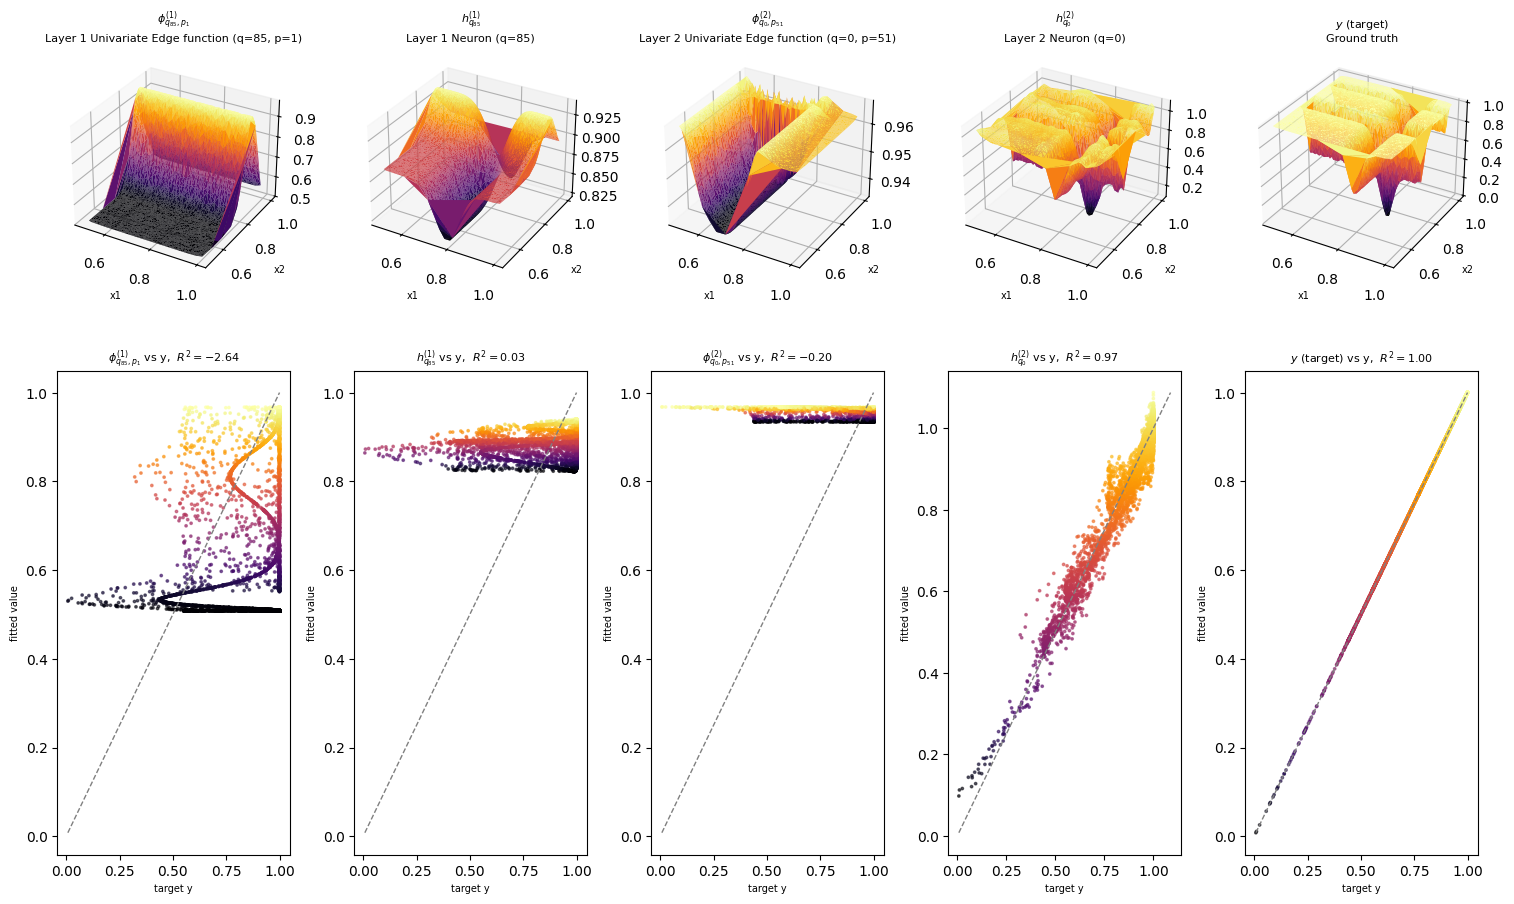

In [60]:
tf5_sgkan_layer_swim_configs = [
    {"layer_width": 100, "num_inducing": 75, "pair_selection_strategy": "swim", "alpha_edge": 1, "alpha_neuron": 0,
     "max_local_points": 1000, "kernel_type": "rbf", "seed": random_seed, "sigma_scale": 1},
    {"layer_width": 1, "num_inducing": 75, "pair_selection_strategy": "swim", "alpha_edge": 1, "alpha_neuron": 0,
     "max_local_points": 1000, "kernel_type": "rbf", "seed": random_seed, "sigma_scale": 1},
]
# A stage item in stages list consists of (layer_idx, phi[q, p, :] edge function results, layer_output) 
tf5_sgkan_stages, tf5_sgkan_ytrain_hat, tf5_sgkan_layer_neurons = sgkan_model.build_sgkan_stack(tf5_x_train, tf5_y_train, tf5_sgkan_layer_swim_configs)
print("TF5 SGKAN train R2:", r2_score(tf5_y_train, tf5_sgkan_ytrain_hat))

visualize.plot_model_stages(tf5_x_train, tf5_y_train, tf5_sgkan_stages, block_idx="random", seed=0)

In [61]:
tf5_sgkan_model = sgkan_model.SGKANModel(tf5_sgkan_layer_swim_configs).fit(tf5_x_train, tf5_y_train)

tf5_sgkan_results = em.evaluate(
    tf5_sgkan_model, tf5_x_train, tf5_y_train, tf5_x_test, tf5_y_test
)
em.print_results(tf5_sgkan_results)

[fit_layer] pair_selection_strategy = 'swim' (layer_width=100, D_in=2)
[fit_layer] local-window method counts over 200 edges: {'interval_capped': 99, 'interval': 101}
[fit_layer] pair_selection_strategy = 'swim' (layer_width=1, D_in=100)
[fit_layer] local-window method counts over 100 edges: {'interval_capped': 77, 'interval': 23}
[SGKANModel.fit] Total fit duration: 3.0261s
Metric          Train                Test                
-------------------------------------------------------
MAE             2.400614e-02         2.509565e-02        
RMSE            3.298632e-02         3.455258e-02        
-------------------------------------------------------
Inference (s)   1.122153             2.505510            


### Optuna - Parameter Search

Find the best layer configuration for TF5 dataset.

In [62]:
tf5_result = sps.study_optuna_sgkan(
    "tf5", tf5_x_train, tf5_y_train, tf5_x_test, tf5_y_test,
    n_trials=375
)

Results found for tf5. Loading from data/tf5_sgkan_optuna_search.csv
Best Validation RMSE:   0.000517082480453
Best Test RMSE:          0.005885402814329
Best layer_width:        750
Best num_inducing:       10
Best alpha_edge:         1.000e+01
Best alpha_neuron:       0.000e+00
Best kernel_type:        rbf

All 375 trials:
     number         value  params_layer_width  params_num_inducing  params_alpha_edge  params_alpha_neuron params_kernel_type      val_rmse     test_rmse
0         0  0.0013083529                1000                   50              0.001                    0             matern  0.0013083529           NaN
1         1  0.0087599801                1000                   25              1.000                    0           periodic  0.0087599801           NaN
2         2  0.0066447025                 500                   50             10.000                    0                rbf  0.0066447025           NaN
3         3  0.0145120250                 500            

In [63]:
# Use best parameter configuration to fit an SGKAN model again
best_tf5_configs = tf5_result["layer_configs"]
best_tf5_configs

[{'layer_width': 750,
  'num_inducing': 10,
  'pair_selection_strategy': 'swim',
  'alpha_edge': 10.0,
  'alpha_neuron': 0.0,
  'max_local_points': 1000,
  'kernel_type': 'rbf',
  'seed': 0,
  'sigma_scale': 1},
 {'layer_width': 1,
  'num_inducing': 10,
  'pair_selection_strategy': 'swim',
  'alpha_edge': 10.0,
  'alpha_neuron': 0.0,
  'max_local_points': 1000,
  'kernel_type': 'rbf',
  'seed': 0,
  'sigma_scale': 1}]

In [64]:
tf5_sgkan_optuna_df = pd.read_csv("data/tf5_sgkan_optuna_search.csv")
tf5_sgkan_optuna_df.sort_values("val_rmse").head(5)

,number,value,datetime_start,datetime_complete,duration,params_alpha_edge,params_alpha_neuron,params_kernel_type,params_layer_width,params_num_inducing,...,fit_duration_sec,kernel_type,user_attrs_layer_width,user_attrs_num_inducing,sigma_scale,val_rmse,system_attrs_grid_id,system_attrs_search_space,state,test_rmse
281,281,0.0005170825,2026-07-30 22:46:28.851588,2026-07-30 22:46:33.651547,4.799959,10.000,0,rbf,750,10,...,4.2833396250,rbf,750,10,1,0.0005170825,281,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,0.0058854028
141,141,0.0006524138,2026-07-30 22:20:25.372663,2026-07-30 22:20:41.236017,15.863354,0.001,0,rbf,1000,50,...,14.6505047500,rbf,1000,50,1,0.0006524138,141,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,NaN
305,305,0.0006579911,2026-07-30 22:52:02.461633,2026-07-30 22:52:08.332670,5.871037,10.000,0,rbf,1000,10,...,5.5797950000,rbf,1000,10,1,0.0006579911,305,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,NaN
282,282,0.0007023510,2026-07-30 22:46:33.655956,2026-07-30 22:47:04.388924,30.732968,0.001,0,rbf,1000,75,...,28.7926407080,rbf,1000,75,1,0.0007023510,282,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,NaN
341,341,0.0007123505,2026-07-30 22:57:28.241498,2026-07-30 22:58:02.576549,34.335051,0.001,0,rbf,1000,100,...,31.9549342919,rbf,1000,100,1,0.0007123505,341,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,NaN


In [65]:
best_tf5_sgkan_model = sgkan_model.SGKANModel(best_tf5_configs).fit(tf5_x_train, tf5_y_train)

best_tf5_sgkan_results = em.evaluate(
    best_tf5_sgkan_model, tf5_x_train, tf5_y_train, tf5_x_test, tf5_y_test
)
em.print_results(best_tf5_sgkan_results)

[fit_layer] pair_selection_strategy = 'swim' (layer_width=750, D_in=2)
[fit_layer] local-window method counts over 1500 edges: {'interval_capped': 814, 'interval': 686}
[fit_layer] pair_selection_strategy = 'swim' (layer_width=1, D_in=750)
[fit_layer] local-window method counts over 750 edges: {'interval': 634, 'interval_capped': 113, 'knn_fallback': 3}
[SGKANModel.fit] Total fit duration: 5.9243s
Metric          Train                Test                
-------------------------------------------------------
MAE             2.958474e-03         3.716510e-03        
RMSE            4.400706e-03         5.885403e-03        
-------------------------------------------------------
Inference (s)   2.047109             2.566088            


In [66]:
# Try best parameter configuration but without SWIM (random projections) this time
# Aim is to see if using SWIM matters
random_best_tf5_configs = [{'layer_width': 750,
  'num_inducing': 10,
  'pair_selection_strategy': 'random',
  'alpha_edge': 10,
  'alpha_neuron': 0,
  'max_local_points': 1000,
  'kernel_type': 'rbf',
  'seed': 0,
  'sigma_scale': 1},
 {'layer_width': 1,
  'num_inducing': 10,
  'pair_selection_strategy': 'random',
  'alpha_edge': 10,
  'alpha_neuron': 0,
  'max_local_points': 1000,
  'kernel_type': 'rbf',
  'seed': 0,
  'sigma_scale': 1}]

In [67]:
random_best_tf5_sgkan_model = sgkan_model.SGKANModel(random_best_tf5_configs).fit(tf5_x_train, tf5_y_train)

random_best_tf5_sgkan_results = em.evaluate(
    random_best_tf5_sgkan_model, tf5_x_train, tf5_y_train, tf5_x_test, tf5_y_test
)
em.print_results(random_best_tf5_sgkan_results)

[fit_layer] pair_selection_strategy = 'random' (layer_width=750, D_in=2)
[fit_layer] local-window method counts over 1500 edges: {'interval': 566, 'interval_capped': 930, 'knn_fallback': 4}
[fit_layer] pair_selection_strategy = 'random' (layer_width=1, D_in=750)
[fit_layer] local-window method counts over 750 edges: {'interval_capped': 536, 'interval': 214}
[SGKANModel.fit] Total fit duration: 4.2505s
Metric          Train                Test                
-------------------------------------------------------
MAE             8.064866e-04         1.090866e-03        
RMSE            1.186171e-03         1.939026e-03        
-------------------------------------------------------
Inference (s)   1.002006             2.002366            


### 50 seed results

Run the best SGKAN model 50 times with different random seeds to compute median and IQR of RMSE, matching the methodology from HKAN's paper for fair comparison. This statistical approach accounts for the randomness in pair selection and provides a robust measure of model performance variability.

In [68]:
tf5_50_runs_path = "data/tf5_sgkan_50_run_results.csv"

if os.path.exists(tf5_50_runs_path):
    tf5_50_runs_df = pd.read_csv("data/tf5_sgkan_50_run_results.csv")
else:
    tf5_50_runs = run_sgkan_seed_experiments(tf5_x_train, tf5_y_train, tf5_x_test, tf5_y_test, best_tf5_configs, n_runs=50)
    tf5_50_runs_df = create_export_seed_results(tf5_50_runs, "tf5_sgkan_50_run_results")

tf5_50_runs_df.head()

,seed,train_mae,train_rmse,train_inference_time_secs,test_mae,test_rmse,test_inference_time_secs
0,0,0.0029584740,0.0044007065,1.6426272500,0.0037165102,0.0058854028,3.286352375
1,1,0.0005981525,0.0008976712,0.9939735419,0.0009103950,0.0030073060,1.903232334
2,2,0.0007026044,0.0010700494,1.4267712500,0.0009819749,0.0020447764,2.485621292
3,3,0.0036049406,0.0052355128,1.5339603750,0.0047373145,0.0085149162,3.198437292
4,4,0.0020831892,0.0032366163,2.4560351250,0.0029747817,0.0070464088,2.664999458


In [69]:
summarize_metrics(tf5_50_runs_df, "SGKAN SWIM")

{'model': 'SGKAN SWIM',
 'train_rmse_median': 0.00201020718202415,
 'train_rmse_iqr': 0.0017228074355058252,
 'test_rmse_median': 0.00330442065710975,
 'test_rmse_iqr': 0.0024084829225426998}

### Hypothesis 1

Increasing layer width (other parameters are constant) vs. RMSE for different models HKAN, SGKAN swim and SGKAN random

Compare how increasing the first layer width affects performance across SGKAN (SWIM), SGKAN (random), and HKAN. All other parameters stay fixed to isolate the width effect. The goal is to understand whether wider layers consistently improve predictions and if this trend differs between the algorithms.

In [70]:
# Best TF5 HKAN configuration from the paper
tf5_hkan_layer_configs = [
    dict(layer=0, n_vars_out=912, n_basis=23, centers="random", basis_fn=Tanh(s=50), expanding_base_regressor=Ridge(alpha=0.01)),
    dict(layer=1, n_vars_out=1, n_basis=1, centers="equally_spaced", basis_fn=Identity(), expanding_base_regressor=None),
]

In [71]:
tf5_hypothesis_1_path = "data/tf5_hypothesis_1_results_df.csv"

if os.path.exists(tf5_hypothesis_1_path):
    tf5_hypothesis_1_results_df = pd.read_csv("data/tf5_hypothesis_1_results_df.csv")
else:
    # Define layer widths
    layer_widths = [2, 10, 25, 50, 100, 250, 500, 750, 1000]

    # Results storage
    results = {
        'sgkan_swim': {'widths': [], 'train_rmse': [], 'test_rmse': []},
        'sgkan_random': {'widths': [], 'train_rmse': [], 'test_rmse': []},
        'hkan': {'widths': [], 'train_rmse': [], 'test_rmse': []}
    }

    # SGKAN with SWIM
    print("Testing SGKAN with SWIM pair selection...")
    for width in layer_widths:
        config = [c.copy() for c in best_tf5_configs]
        config[0]['layer_width'] = width
        model = sgkan_model.SGKANModel(config).fit(tf5_x_train, tf5_y_train)
        eval_results = em.evaluate(model, tf5_x_train, tf5_y_train, tf5_x_test, tf5_y_test)
        results['sgkan_swim']['widths'].append(width)
        results['sgkan_swim']['train_rmse'].append(eval_results['train']['rmse'])
        results['sgkan_swim']['test_rmse'].append(eval_results['test']['rmse'])
        print(f"  Width {width}: Train RMSE={eval_results['train']['rmse']:.6e}, Test RMSE={eval_results['test']['rmse']:.6e}")

    # SGKAN with random pair selection
    print("\nTesting SGKAN with random pair selection...")
    for width in layer_widths:
        config = [c.copy() for c in best_tf5_configs]
        config[0]['pair_selection_strategy'] = 'random'
        config[0]['layer_width'] = width
        config[1]['pair_selection_strategy'] = 'random'
        model = sgkan_model.SGKANModel(config).fit(tf5_x_train, tf5_y_train)
        eval_results = em.evaluate(model, tf5_x_train, tf5_y_train, tf5_x_test, tf5_y_test)
        results['sgkan_random']['widths'].append(width)
        results['sgkan_random']['train_rmse'].append(eval_results['train']['rmse'])
        results['sgkan_random']['test_rmse'].append(eval_results['test']['rmse'])
        print(f"  Width {width}: Train RMSE={eval_results['train']['rmse']:.6e}, Test RMSE={eval_results['test']['rmse']:.6e}")

    # HKAN with best config
    print("\nTesting HKAN...")
    for width in layer_widths:
        config = [c.copy() for c in tf5_hkan_layer_configs]
        config[0]['n_vars_out'] = width
        model = utils.build_hkan_model_from_configs(config, tqdm_disable=True)
        utils.fit_hkan(model, tf5_x_train, tf5_y_train)
        eval_results = em.evaluate(model, tf5_x_train, tf5_y_train, tf5_x_test, tf5_y_test)
        results['hkan']['widths'].append(width)
        results['hkan']['train_rmse'].append(eval_results['train']['rmse'])
        results['hkan']['test_rmse'].append(eval_results['test']['rmse'])
        print(f"  Width {width}: Train RMSE={eval_results['train']['rmse']:.6e}, Test RMSE={eval_results['test']['rmse']:.6e}")

    # Display results
    tf5_hypothesis_1_results_df = pd.DataFrame({
        'layer_width': layer_widths,
        'sgkan_swim_train_rmse': results['sgkan_swim']['train_rmse'],
        'sgkan_swim_test_rmse': results['sgkan_swim']['test_rmse'],
        'sgkan_random_train_rmse': results['sgkan_random']['train_rmse'],
        'sgkan_random_test_rmse': results['sgkan_random']['test_rmse'],
        'hkan_train_rmse': results['hkan']['train_rmse'],
        'hkan_test_rmse': results['hkan']['test_rmse']
    })
    tf5_hypothesis_1_results_df.to_csv("data/tf5_hypothesis_1_results_df.csv")

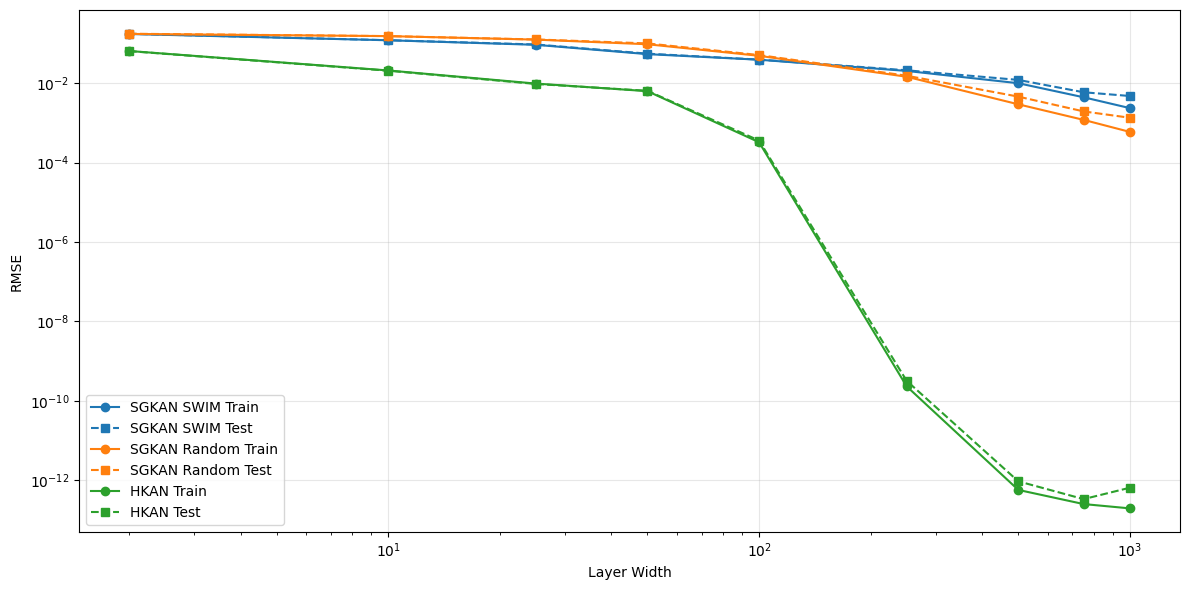

In [72]:
plot_hypothesis_1_results(tf5_hypothesis_1_results_df)

In [73]:
tf5_hypothesis_1_results_df

,Unnamed: 0,layer_width,sgkan_swim_train_rmse,sgkan_swim_test_rmse,sgkan_random_train_rmse,sgkan_random_test_rmse,hkan_train_rmse,hkan_test_rmse
0,0,2,0.1728894170,0.1750694977,0.1735104710,0.1754209307,6.4546567273e-02,6.4071827068e-02
1,1,10,0.1200821814,0.1205149027,0.1528609080,0.1528862136,2.0839835272e-02,2.0561532242e-02
2,2,25,0.0923189326,0.0940544493,0.1246577874,0.1258681346,9.7404972970e-03,9.5282230397e-03
3,3,50,0.0537268476,0.0552413465,0.0952992393,0.1000534398,6.2726721506e-03,6.4058906150e-03
4,4,100,0.0388654060,0.0391149692,0.0487785180,0.0509372262,3.2453874761e-04,3.5747409705e-04
5,5,250,0.0202883421,0.0210514813,0.0144811474,0.0153707704,2.3019010054e-10,3.1719994400e-10
6,6,500,0.0099474998,0.0120460396,0.0029266004,0.0045682441,5.6602262574e-13,9.3177315679e-13
7,7,750,0.0044007065,0.0058854028,0.0011861714,0.0019390262,2.4914441352e-13,3.3194464294e-13
8,8,1000,0.0023440576,0.0047359011,0.0005895085,0.0013406663,1.9381044444e-13,6.4336637848e-13


### Explore Feature importances and Layers

Examine how well each input feature is being captured by the first layer of the best model. This helps us understand which input dimensions are most important and how the model processes the input space.

In [74]:
best_tf5_configs

[{'layer_width': 750,
  'num_inducing': 10,
  'pair_selection_strategy': 'swim',
  'alpha_edge': 10.0,
  'alpha_neuron': 0.0,
  'max_local_points': 1000,
  'kernel_type': 'rbf',
  'seed': 0,
  'sigma_scale': 1},
 {'layer_width': 1,
  'num_inducing': 10,
  'pair_selection_strategy': 'swim',
  'alpha_edge': 10.0,
  'alpha_neuron': 0.0,
  'max_local_points': 1000,
  'kernel_type': 'rbf',
  'seed': 0,
  'sigma_scale': 1}]

[build_sgkan_stack] Layer 1: pair_selection_strategy = 'swim'
[fit_layer] pair_selection_strategy = 'swim' (layer_width=750, D_in=2)
[fit_layer] local-window method counts over 1500 edges: {'interval_capped': 814, 'interval': 686}
[build_sgkan_stack] Layer 2: pair_selection_strategy = 'swim'
[fit_layer] pair_selection_strategy = 'swim' (layer_width=1, D_in=750)
[fit_layer] local-window method counts over 750 edges: {'interval': 634, 'interval_capped': 113, 'knn_fallback': 3}


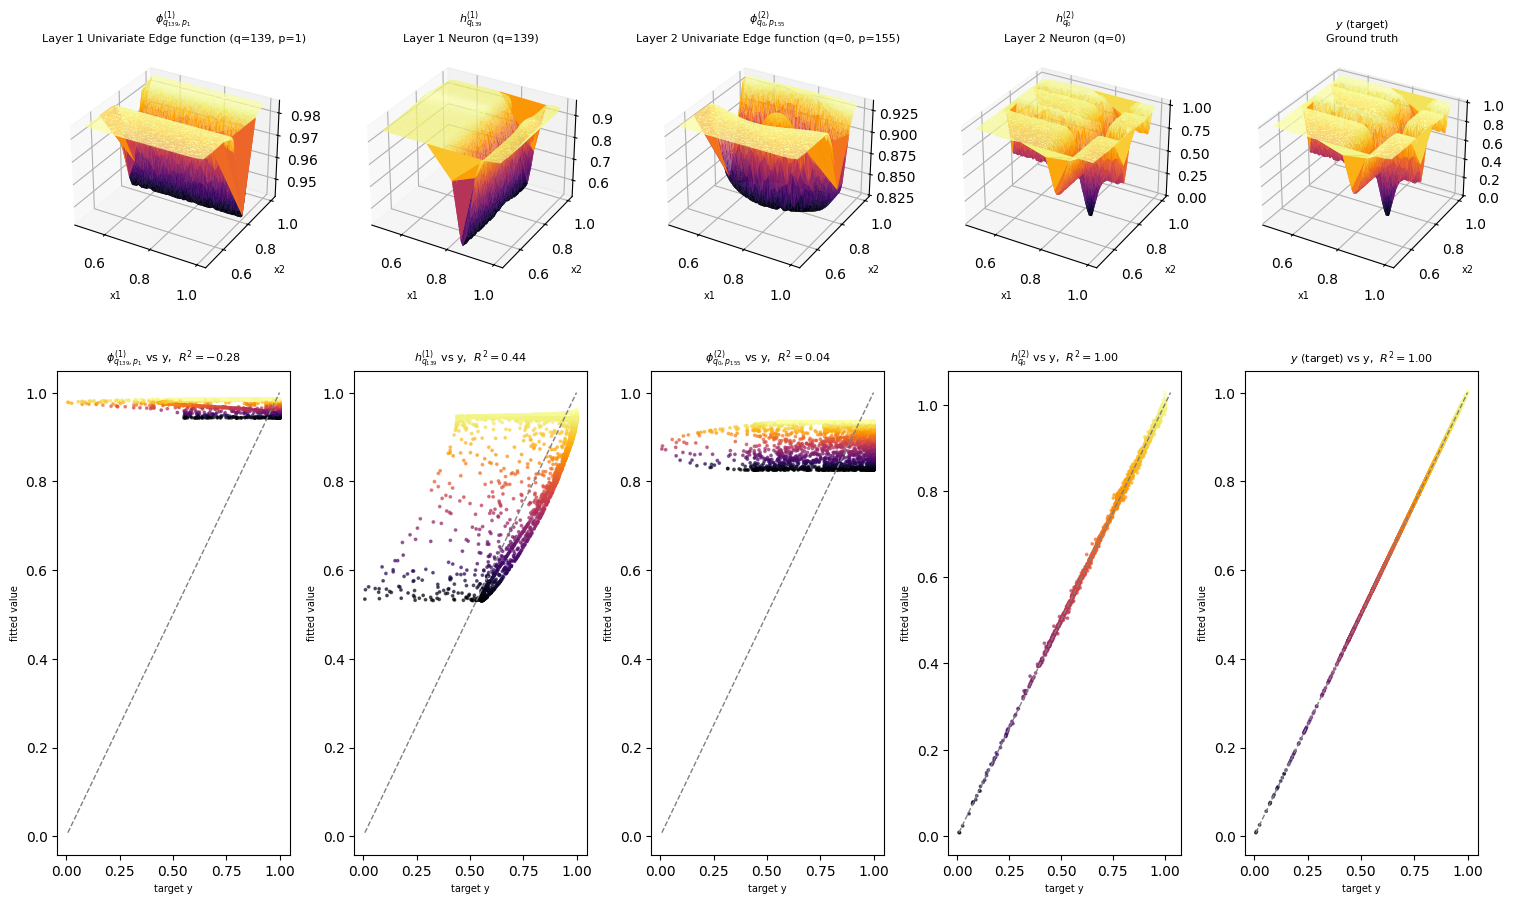

In [75]:
best_tf5_sgkan_stages, best_tf5_sgkan_ytrain_hat, best_tf5_sgkan_layer_neurons = sgkan_model.build_sgkan_stack(tf5_x_train, tf5_y_train, best_tf5_configs)
visualize.plot_model_stages(tf5_x_train, tf5_y_train, best_tf5_sgkan_stages, block_idx="random")

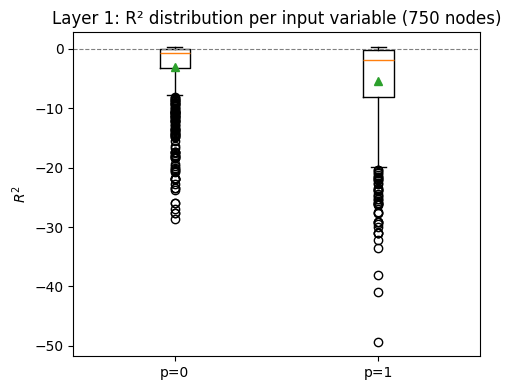

In [76]:
visualize.plot_first_layer_featurewise_r2_summary(best_tf5_sgkan_stages, tf5_y_train)

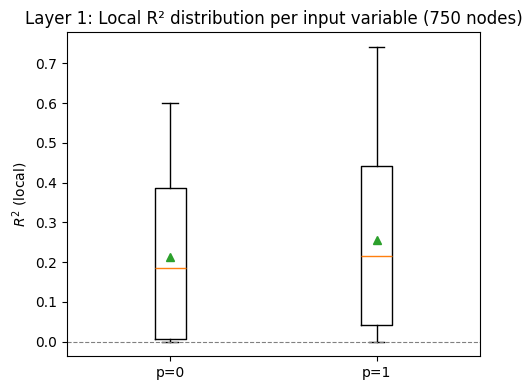

In [77]:
plot_first_layer_local_edge_r2_summary(best_tf5_sgkan_layer_neurons)